# Plots for Long-Run Experiments

Clean plotting notebook for paper-style figures. Each section writes high-quality `png` and `svg` files to `./plots` and keeps `plt.show()` as a lightweight preview. Heavy debugging output from `TEST_NEW_DATA.ipynb` is intentionally omitted.


In [17]:
import os
from pathlib import Path

MPLCONFIGDIR = Path('/tmp/matplotlib-weiji')
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIGDIR))

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from scipy.stats import pearsonr, ttest_ind, ttest_1samp

NOTEBOOK_DIR = Path('/home/weiji/restart_exam/code_cleaned/Longrun/Visualization')
PLOT_DIR = NOTEBOOK_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    'figure.dpi': 90,
    'savefig.dpi': 320,
    'font.family': 'sans-serif',
    'axes.linewidth': 1.0,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
})

HIGH_DPI = 360
PREVIEW_DPI = 85
SAVE_SVG = True
SAVE_PNG = True


def save_and_show(fig, stem, preview_dpi=PREVIEW_DPI, tight=True):
    """Save high-quality PNG/SVG and keep the in-notebook preview light."""
    saved = []
    if SAVE_PNG:
        png = PLOT_DIR / f'{stem}.png'
        fig.savefig(png, dpi=HIGH_DPI, bbox_inches='tight' if tight else None)
        saved.append(png)
    if SAVE_SVG:
        svg = PLOT_DIR / f'{stem}.svg'
        fig.savefig(svg, bbox_inches='tight' if tight else None)
        saved.append(svg)
    fig.set_dpi(preview_dpi)
    print('saved:', ', '.join(str(p) for p in saved))
    plt.show()
    return saved


def month_ticks_mar_may(ax):
    ax.set_xticks([0, 31, 61, 91])
    ax.set_xticklabels(['Mar', 'Apr', 'May', 'June'])


def normalize_plev_to_hpa(da):
    p = np.asarray(da['plev'].values, dtype=float)
    return da.assign_coords(plev=p / 100.0 if np.nanmax(np.abs(p)) > 1000 else p)


def sel_lat_band(da, lat_min, lat_max):
    lat = da['lat'].values
    if float(lat[0]) <= float(lat[-1]):
        return da.sel(lat=slice(lat_min, lat_max))
    return da.sel(lat=slice(lat_max, lat_min))


def coslat_weighted_mean(da, lat_min, lat_max):
    da = sel_lat_band(da, lat_min, lat_max)
    weights = np.cos(np.deg2rad(da['lat']))
    return da.weighted(weights).mean('lat')


def select_plev_hpa(da, target_hpa):
    da = normalize_plev_to_hpa(da)
    return da.sel(plev=target_hpa, method='nearest')


def date_to_doy_no_leap(date_values):
    date_values = np.asarray(date_values, dtype=np.int64)
    mmdd = date_values % 10000
    month = (mmdd // 100).astype(np.int16)
    day = (mmdd % 100).astype(np.int16)
    month_ends = np.array([31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334, 365])
    doy = np.full(date_values.shape, -9999, dtype=np.int16)
    for m in range(1, 13):
        mask = month == m
        if np.any(mask):
            prev = int(month_ends[m - 2]) if m > 1 else 0
            doy[mask] = prev + day[mask]
    return doy.astype(int)


def calendar_from_time_values(time_values):
    day_index = np.asarray(time_values, dtype=float).astype(np.int64)
    years = day_index // 365 + 1
    doys = day_index % 365 + 1
    return years.astype(int), doys.astype(int)


def calendar_from_dataset(ds):
    if 'date' in ds:
        dates = ds['date'].values.astype(np.int64)
        return (dates // 10000).astype(int), date_to_doy_no_leap(dates)
    return calendar_from_time_values(ds['time'].values)


## TEST_NEW_DATA Composite Diagnostics

Raw and 5-day running-mean ozone-year selection versions of the 3 x 3 diagnostic figure, without the debug sanity-print blocks.


In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import pearsonr

# ============================================================
# INT-3D / CLIM 2D / CLIM 3D combined 3-column figure
# Mirrors the Combined_Reanalysis_WACCM4_INT3D_NAM_AO_EPFlux_O3_2x3 logic,
# but uses outputs from Nam_calculation.ipynb and Partial_O3_with_ranking.ipynb.
# Clean plotting copy: save_and_show handles output and lightweight preview.
# ============================================================

COMPONENT_CASES = {
    "BWCN": {
        "label": "BWCN",
        "nam_nc": "/mnt/soclim0/public_data/weiji/BWCN/NAM/BWCN_Vertical_NAM.nc",
        "ao_csv": "/mnt/soclim0/public_data/weiji/BWCN/NAM/BWCN_Daily_AO_Index.csv",
        "ep_nc": "/mnt/soclim0/public_data/weiji/BWCN/EPflux_daily/all_waves/EPFLUX_all_waves_24yr_time_plev_lat.nc",
        "o3_rank_csv": "/mnt/soclim0/public_data/weiji/BWCN/partial_O3/BWCN_partial_O3_ranking_MarApr_min_60_90N.csv",
        "o3_partial_nc": "/mnt/soclim0/public_data/weiji/BWCN/partial_O3/BWCN_partial_O3_all_ranges.nc",
    },
    "B2000WCN": {
        "label": "B2000WCN",
        "nam_nc": "/mnt/soclim0/public_data/weiji/B2000WCN001002_timefixed/NAM/B2000WCN001002_Vertical_NAM.nc",
        "ao_csv": "/mnt/soclim0/public_data/weiji/B2000WCN001002_timefixed/NAM/B2000WCN001002_Daily_AO_Index.csv",
        "ep_nc": "/mnt/soclim0/public_data/weiji/B2000WCN001002_timefixed/EPflux_daily/all_waves/EPFLUX_all_waves_210yr_time_plev_lat.nc",
        "o3_rank_csv": "/mnt/soclim0/public_data/weiji/B2000WCN001002_timefixed/partial_O3/B2000WCN_partial_O3_ranking_MarApr_min_60_90N.csv",
        "o3_partial_nc": "/mnt/soclim0/public_data/weiji/B2000WCN001002_timefixed/partial_O3/B2000WCN_partial_O3_all_ranges.nc",
    },
    "B2000WCN_NOCOUPL": {
        "label": "B2000WCN_NOCOUPL",
        "nam_nc": "/mnt/soclim0/public_data/weiji/B2000WCN_NOCOUPL001002_timefixed/NAM/B2000WCN_NOCOUPL001002_Vertical_NAM.nc",
        "ao_csv": "/mnt/soclim0/public_data/weiji/B2000WCN_NOCOUPL001002_timefixed/NAM/B2000WCN_NOCOUPL001002_Daily_AO_Index.csv",
        "ep_nc": "/mnt/soclim0/public_data/weiji/B2000WCN_NOCOUPL001002_timefixed/EPflux_daily/all_waves/EPFLUX_all_waves_205yr_time_plev_lat.nc",
        "o3_rank_csv": "/mnt/soclim0/public_data/weiji/B2000WCN_NOCOUPL001002_timefixed/partial_O3/B2000WCN_NOCOUPL_partial_O3_ranking_MarApr_min_60_90N.csv",
        "o3_partial_nc": "/mnt/soclim0/public_data/weiji/B2000WCN_NOCOUPL001002_timefixed/partial_O3/B2000WCN_NOCOUPL_partial_O3_all_ranges.nc",
    },
    "B2000WCN007009010011_Clim3D": {
        "label": "B2000WCN007009010011_Clim3D",
        "nam_nc": "/mnt/soclim0/public_data/weiji/B2000WCN007009010011_Clim3D_timefixed/NAM/B2000WCN007009010011_Clim3D_Vertical_NAM.nc",
        "ao_csv": "/mnt/soclim0/public_data/weiji/B2000WCN007009010011_Clim3D_timefixed/NAM/B2000WCN007009010011_Clim3D_Daily_AO_Index.csv",
        "ep_nc": "/mnt/soclim0/public_data/weiji/B2000WCN007009010011_Clim3D_timefixed/EPflux_daily/all_waves/EPFLUX_all_waves_216yr_time_plev_lat.nc",
        "o3_rank_csv": "/mnt/soclim0/public_data/weiji/B2000WCN007009010011_Clim3D_timefixed/partial_O3/B2000WCN007009010011_Clim3D_partial_O3_ranking_MarApr_min_60_90N.csv",
        "o3_partial_nc": "/mnt/soclim0/public_data/weiji/B2000WCN007009010011_Clim3D_timefixed/partial_O3/B2000WCN007009010011_Clim3D_partial_O3_all_ranges.nc",
    },
}

PLOT_ROWS = [
    {"label": "INT-3D", "case_keys": ["BWCN", "B2000WCN"]},
    {"label": "CLIM 2D", "case_keys": ["B2000WCN_NOCOUPL"]},
    {"label": "CLIM 3D", "case_keys": ["B2000WCN007009010011_Clim3D"]},
]

EPFLUX_PLOT_VARIANTS = {
    "legacy": {
        "label": "no DO_UBAR / no omega correction",
        "daily_subdir": "EPflux_daily",
        "stem_suffix": "no_doubar",
    },
    "ubar_wcorr": {
        "label": "DO_UBAR + omega correction",
        "daily_subdir": "EPflux_daily_ubar_wcorr",
        "stem_suffix": "doubar_omega",
    },
}
DEFAULT_EPFLUX_VARIANT = "legacy"

LAT_FZ = (40.0, 80.0)
PRESSURE_TAG = "30_70hPa"
MONTH_ENDS_NOLEAP = np.array([31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334, 365])

FIGSIZE = (17.2, 12.0)
FIG_HEIGHT_PER_ROW = FIGSIZE[1] / 2.0
PANEL_BOX_ASPECT = 1.0
TITLE_SIZE = 19
ROW_LABEL_SIZE = 17
LABEL_SIZE = 16
TICK_SIZE = 14
TEXT_SIZE = 13
LEGEND_SIZE = 14

STD_LIMIT = (-3.0, 3.0)
O3_YLIM = (70.0, 120.0)
O3_YTICKS = np.arange(70, 121, 10)
O3_VALID_MIN_DU = 10.0
O3_MARAPR_MIN_VALID_DAYS = 40
STD_TICKS = np.arange(-3, 4, 1)

BASE_COLOR = "0.25"
BASE_ALPHA = 0.42
LOW25_COLOR = "red"
TOP1_COLOR = "gold"
FIT_COLOR = "0.35"

BASE_SIZE = 58
LOW25_SIZE = 68
TOP1_SIZE = 260


def model_calendar_from_time(time_values):
    day_index = np.asarray(time_values, dtype=float).astype(np.int64)
    year = day_index // 365 + 1
    doy = day_index % 365 + 1
    month = np.searchsorted(MONTH_ENDS_NOLEAP, doy, side="left") + 1
    return year.astype(int), month.astype(int), doy.astype(int)


def add_model_calendar(da):
    year, month, doy = model_calendar_from_time(da["time"].values)
    return da.assign_coords(
        model_year=("time", year),
        model_month=("time", month),
        model_doy=("time", doy),
    )


def select_pressure_level_safe(da, coord_name, target_hpa, case_name="", var_name=""):
    vals = np.asarray(da[coord_name].values, dtype=float)
    target = target_hpa * 100.0 if np.nanmax(np.abs(vals)) > 2000 else target_hpa
    selected = float(da[coord_name].sel({coord_name: target}, method="nearest").values)
    unit_guess = "Pa" if np.nanmax(np.abs(vals)) > 2000 else "hPa"
    print(
        f"    [{case_name}] {var_name}: coord={coord_name}, "
        f"unit_guess={unit_guess}, target={target_hpa:g} hPa, selected={selected:g}"
    )
    return da.sel({coord_name: target}, method="nearest")


def sel_lat_safe(da, lat_range):
    lat0, lat1 = lat_range
    lat = da["lat"]
    if float(lat.values[0]) > float(lat.values[-1]):
        return da.sel(lat=slice(lat1, lat0))
    return da.sel(lat=slice(lat0, lat1))


def coslat_mean(da, lat_range):
    da_sub = sel_lat_safe(da, lat_range)
    weights = np.cos(np.deg2rad(da_sub["lat"]))
    return da_sub.weighted(weights).mean("lat", skipna=True)


def epflux_variant_label(epflux_variant):
    return EPFLUX_PLOT_VARIANTS[epflux_variant]["label"]


def epflux_path_for_variant(ep_nc, epflux_variant=DEFAULT_EPFLUX_VARIANT):
    cfg = EPFLUX_PLOT_VARIANTS[epflux_variant]
    if cfg["daily_subdir"] == "EPflux_daily":
        return ep_nc
    return ep_nc.replace("/EPflux_daily/", f"/{cfg['daily_subdir']}/")


def component_epflux_missing(epflux_variant=DEFAULT_EPFLUX_VARIANT):
    missing = []
    for case_key, info in COMPONENT_CASES.items():
        path = epflux_path_for_variant(info["ep_nc"], epflux_variant)
        if not os.path.exists(path):
            missing.append((case_key, info["label"], path))
    return missing


def jfm_mean_from_model_time(da):
    da = add_model_calendar(da)
    jfm = da.where(da["model_month"].isin([1, 2, 3]), drop=True)
    return jfm.groupby("model_year").mean("time").rename({"model_year": "year"})


def djf_mean_from_model_time(da):
    da = add_model_calendar(da)
    djf_year = xr.where(da["model_month"] == 12, da["model_year"] + 1, da["model_year"])
    da = da.assign_coords(djf_year=("time", np.asarray(djf_year.values, dtype=int)))
    djf = da.where(da["model_month"].isin([12, 1, 2]), drop=True)
    return djf.groupby("djf_year").mean("time").rename({"djf_year": "year"})


def load_nam_jfm(nam_nc, case_name):
    ds = xr.open_dataset(nam_nc, decode_times=False)
    try:
        var_name = "NAM" if "NAM" in ds.data_vars else "NAM_Vertical"
        da = ds[var_name]
        lev_coord = next(c for c in ["lev", "level", "plev"] if c in da.coords or c in da.dims)
        da50 = select_pressure_level_safe(da, lev_coord, 50.0, case_name=case_name, var_name=var_name)
        return jfm_mean_from_model_time(da50)
    finally:
        ds.close()


def load_ao_jfm(ao_csv):
    df = pd.read_csv(ao_csv)
    date = df["Date"].astype(str)
    df["year"] = date.str.slice(0, 4).astype(int)
    df["month"] = date.str.slice(5, 7).astype(int)
    jfm = df[df["month"].isin([1, 2, 3])].groupby("year")["AO_Index"].mean()
    return xr.DataArray(jfm.values, coords={"year": jfm.index.values.astype(int)}, dims=["year"])


def load_ep_djf(ep_nc, case_name):
    ds = xr.open_dataset(ep_nc, decode_times=False)
    try:
        if "Fz" in ds.data_vars:
            var_name = "Fz"
        elif "EP2_cart" in ds.data_vars:
            var_name = "EP2_cart"
        elif "ep2" in ds.data_vars:
            var_name = "ep2"
        else:
            var_name = list(ds.data_vars)[0]

        da = ds[var_name]
        p_coord = next(c for c in ["plev", "lev", "level"] if c in da.coords or c in da.dims)
        da100 = select_pressure_level_safe(da, p_coord, 100.0, case_name=case_name, var_name=var_name)
        if "lat" in da100.coords:
            da100 = coslat_mean(da100, LAT_FZ)
        da100 = -1.0 * da100
        return djf_mean_from_model_time(da100)
    finally:
        ds.close()


def date_to_doy_no_leap(date_values):
    date_values = np.asarray(date_values, dtype=np.int64)
    mmdd = date_values % 10000
    month = (mmdd // 100).astype(np.int16)
    day = (mmdd % 100).astype(np.int16)
    doy = np.full(date_values.shape, -9999, dtype=np.int16)
    for m in range(1, 13):
        mask = month == m
        if np.any(mask):
            prev = int(MONTH_ENDS_NOLEAP[m - 2]) if m > 1 else 0
            doy[mask] = prev + day[mask]
    return doy


def partial_o3_calendar_from_ds(ds):
    if "date" in ds:
        dates = ds["date"].values.astype(np.int64)
        years = (dates // 10000).astype(np.int32)
        doys = date_to_doy_no_leap(dates)
        return years.astype(int), doys.astype(int)
    years, _, doys = model_calendar_from_time(ds["time"].values)
    return years.astype(int), doys.astype(int)


def load_o3_ranking_from_partial_nc(partial_o3_nc, pressure_tag=PRESSURE_TAG, rolling_days=5):
    ds = xr.open_dataset(partial_o3_nc, decode_times=False)
    try:
        if "O3_partial_60_90N" in ds:
            da = ds["O3_partial_60_90N"].sel(pressure_range=pressure_tag)
        else:
            name = f"O3_partial_60_90N_{pressure_tag}"
            if name not in ds:
                raise KeyError(f"Cannot find {name} or O3_partial_60_90N in {partial_o3_nc}")
            da = ds[name]

        years, doys = partial_o3_calendar_from_ds(ds)
        # Near-zero/non-positive partial columns are fill/break artifacts here.
        # Mask them before rolling so a bad day cannot become the annual minimum.
        da = da.where(da > O3_VALID_MIN_DU)
        if rolling_days is not None and int(rolling_days) > 1:
            da = da.rolling(time=int(rolling_days), center=True, min_periods=int(rolling_days)).mean()
        o3 = da.load().values.astype(float)
    finally:
        ds.close()

    daily = pd.DataFrame({"year": years, "doy": doys, "o3_raw": o3})
    marapr = daily[(daily["doy"] >= 60) & (daily["doy"] <= 120)].copy()
    marapr["is_valid_o3"] = np.isfinite(marapr["o3_raw"]) & (marapr["o3_raw"] > O3_VALID_MIN_DU)

    stats = (
        marapr.groupby("year", as_index=False)
        .agg(
            o3_raw=("o3_raw", lambda x: np.nanmin(x.values) if np.any(np.isfinite(x.values)) else np.nan),
            n_valid_o3_days=("is_valid_o3", "sum"),
        )
    )
    bad = stats[
        (~np.isfinite(stats["o3_raw"]))
        | (stats["o3_raw"] <= O3_VALID_MIN_DU)
        | (stats["n_valid_o3_days"] < O3_MARAPR_MIN_VALID_DAYS)
    ].copy()
    if len(bad):
        print(
            f"[WARN] Excluding {len(bad)} years from {partial_o3_nc} {pressure_tag} "
            f"rolling={rolling_days}: min O3 <= {O3_VALID_MIN_DU:g} DU or valid Mar-Apr days < {O3_MARAPR_MIN_VALID_DAYS}"
        )
        print(bad[["year", "o3_raw", "n_valid_o3_days"]].head(20).to_string(index=False))

    df = stats[
        np.isfinite(stats["o3_raw"])
        & (stats["o3_raw"] > O3_VALID_MIN_DU)
        & (stats["n_valid_o3_days"] >= O3_MARAPR_MIN_VALID_DAYS)
    ].copy()
    df["year"] = df["year"].astype(int)
    df = df.sort_values("o3_raw", ascending=True).reset_index(drop=True)
    df["rank_low_o3"] = np.arange(1, len(df) + 1, dtype=int)
    n_low25 = max(int(0.25 * len(df)), 1) if len(df) else 0
    df["is_low25"] = df["rank_low_o3"].le(n_low25)
    return df[["year", "o3_raw", "is_low25", "rank_low_o3"]].reset_index(drop=True)

def load_o3_ranking(o3_rank_csv, pressure_tag=PRESSURE_TAG, partial_o3_nc=None, rolling_days=None):
    if rolling_days is not None:
        if partial_o3_nc is None:
            raise ValueError("partial_o3_nc is required for rolling-mean O3 ranking")
        return load_o3_ranking_from_partial_nc(partial_o3_nc, pressure_tag=pressure_tag, rolling_days=rolling_days)

    df = pd.read_csv(o3_rank_csv)
    df = df[df["pressure_range"].astype(str).eq(pressure_tag)].copy()
    df["year"] = pd.to_numeric(df["year"], errors="coerce")

    # Partial_O3_with_ranking now writes both raw and rm5 columns.  Older CSVs
    # used un-suffixed names, so keep both paths readable.
    min_col = "marapr_min_DU_raw" if "marapr_min_DU_raw" in df.columns else "marapr_min_DU"
    rank_col = "rank_low_o3_raw" if "rank_low_o3_raw" in df.columns else "rank_low_o3"
    flag_col = "is_lowest25pct_raw" if "is_lowest25pct_raw" in df.columns else None
    if min_col not in df.columns:
        raise KeyError(f"Cannot find raw March-April O3 minimum column in {o3_rank_csv}")

    df["o3_raw"] = pd.to_numeric(df[min_col], errors="coerce")
    df = df[
        np.isfinite(df["year"])
        & np.isfinite(df["o3_raw"])
        & (df["year"] > 0)
        & (df["o3_raw"] > O3_VALID_MIN_DU)
    ].copy()
    df["year"] = df["year"].astype(int)

    if rank_col in df.columns:
        df["rank_low_o3"] = pd.to_numeric(df[rank_col], errors="coerce")
        df = df.sort_values(["rank_low_o3", "o3_raw"], ascending=True).reset_index(drop=True)
    else:
        df = df.sort_values("o3_raw", ascending=True).reset_index(drop=True)
        df["rank_low_o3"] = np.arange(1, len(df) + 1, dtype=int)

    if flag_col is not None:
        df["is_low25"] = df[flag_col].astype(bool)
    else:
        n_low25 = max(int(0.25 * len(df)), 1) if len(df) else 0
        df["is_low25"] = df["rank_low_o3"].le(n_low25)
    return df[["year", "o3_raw", "is_low25", "rank_low_o3"]].reset_index(drop=True)



def standardize_column(df, cols, prefix_note=""):
    df = df.copy()
    for col in cols:
        mu = df[col].mean()
        sd = df[col].std(ddof=0)
        if not np.isfinite(sd) or sd == 0:
            raise ValueError(f"{prefix_note} cannot standardize {col}: std={sd}")
        df[col.replace("_raw", "")] = (df[col] - mu) / sd
    return df


def standardize_ep_o3_df(df, prefix_note=""):
    df = df.copy().dropna(subset=["fz_raw", "o3_raw"])
    mu = df["fz_raw"].mean()
    sd = df["fz_raw"].std(ddof=0)
    if not np.isfinite(sd) or sd == 0:
        raise ValueError(f"{prefix_note} cannot standardize fz_raw: std={sd}")
    df["fz"] = (df["fz_raw"] - mu) / sd
    return df


def prep_component_case(case_key, info, o3_rolling_days=None, epflux_variant=DEFAULT_EPFLUX_VARIANT):
    ep_path = epflux_path_for_variant(info["ep_nc"], epflux_variant)
    ep_label = epflux_variant_label(epflux_variant)
    print(f"\nBuilding aligned component table: {info['label']} | EP flux: {ep_label}")
    da_nam = load_nam_jfm(info["nam_nc"], info["label"])
    da_ao = load_ao_jfm(info["ao_csv"])
    da_fz = load_ep_djf(ep_path, f"{info['label']} [{ep_label}]")
    df_o3_rank = load_o3_ranking(info["o3_rank_csv"], partial_o3_nc=info.get("o3_partial_nc"), rolling_days=o3_rolling_days)
    low25_set = set(df_o3_rank.loc[df_o3_rank["is_low25"], "year"].astype(int))
    o3_by_year = df_o3_rank.set_index("year")["o3_raw"]

    common_years = np.intersect1d(da_nam.year.values.astype(int), da_ao.year.values.astype(int))
    common_years = np.intersect1d(common_years, da_fz.year.values.astype(int))
    common_years = np.intersect1d(common_years, df_o3_rank["year"].values.astype(int))
    common_years = np.sort(common_years.astype(int))

    df_struct = pd.DataFrame({
        "exp": case_key,
        "year": common_years,
        "nam_raw": da_nam.sel(year=common_years).values.astype(float),
        "fz_raw": da_fz.sel(year=common_years).values.astype(float),
        "ao_raw": da_ao.sel(year=common_years).values.astype(float),
        "o3_raw": o3_by_year.loc[common_years].values.astype(float),
    })
    df_struct["is_low25"] = df_struct["year"].astype(int).isin(low25_set)
    df_struct = df_struct.dropna(subset=["nam_raw", "fz_raw", "ao_raw", "o3_raw"]).reset_index(drop=True)

    df_o3 = pd.DataFrame({
        "exp": case_key,
        "year": common_years,
        "fz_raw": da_fz.sel(year=common_years).values.astype(float),
        "o3_raw": o3_by_year.loc[common_years].values.astype(float),
    })
    df_o3["is_low25"] = df_o3["year"].astype(int).isin(low25_set)
    df_o3 = df_o3.dropna(subset=["fz_raw", "o3_raw"]).reset_index(drop=True)

    print(
        f"    common years: {common_years.min() if len(common_years) else 'NA'}-"
        f"{common_years.max() if len(common_years) else 'NA'}, n={len(common_years)}, "
        f"low25={int(df_struct['is_low25'].sum())}"
    )
    return df_struct, df_o3


def apply_row_level_low25(df_struct, df_o3, row_label):
    """Select low-O3 25% after all components in a plotted row are combined."""
    df_struct = df_struct.copy()
    df_o3 = df_o3.copy()
    n_low25 = max(int(0.25 * len(df_o3)), 1) if len(df_o3) else 0
    low_rows = df_o3.sort_values("o3_raw", ascending=True).head(n_low25)
    if "exp" in df_o3.columns:
        low_keys = set(zip(low_rows["exp"].astype(str), low_rows["year"].astype(int)))
        df_o3["is_low25"] = [
            (str(exp), int(year)) in low_keys
            for exp, year in zip(df_o3["exp"], df_o3["year"])
        ]
        df_struct["is_low25"] = [
            (str(exp), int(year)) in low_keys
            for exp, year in zip(df_struct["exp"], df_struct["year"])
        ]
    else:
        low_years = set(low_rows["year"].astype(int))
        df_o3["is_low25"] = df_o3["year"].astype(int).isin(low_years)
        df_struct["is_low25"] = df_struct["year"].astype(int).isin(low_years)
    print(
        f"    [{row_label}] row-level low25 selected after component merge: "
        f"{int(df_o3['is_low25'].sum())}/{len(df_o3)}"
    )
    return df_struct, df_o3


def prep_plot_row(row_spec, o3_rolling_days=None, epflux_variant=DEFAULT_EPFLUX_VARIANT):
    struct_parts = []
    o3_parts = []
    for case_key in row_spec["case_keys"]:
        df_struct, df_o3 = prep_component_case(
            case_key,
            COMPONENT_CASES[case_key],
            o3_rolling_days=o3_rolling_days,
            epflux_variant=epflux_variant,
        )
        struct_parts.append(df_struct)
        o3_parts.append(df_o3)

    df_struct = pd.concat(struct_parts, ignore_index=True).dropna(subset=["nam_raw", "fz_raw", "ao_raw", "o3_raw"]).reset_index(drop=True)
    df_o3 = pd.concat(o3_parts, ignore_index=True).dropna(subset=["fz_raw", "o3_raw"]).reset_index(drop=True)
    df_struct, df_o3 = apply_row_level_low25(df_struct, df_o3, row_spec["label"])

    df_struct = standardize_column(df_struct, ["nam_raw", "fz_raw", "ao_raw"], prefix_note=row_spec["label"])
    df_o3 = standardize_ep_o3_df(df_o3, prefix_note=row_spec["label"])

    print(
        f"\nAligned plot row: {row_spec['label']} "
        f"EP flux={epflux_variant_label(epflux_variant)}, "
        f"components={','.join(row_spec['case_keys'])}, "
        f"struct_n={len(df_struct)}, o3_n={len(df_o3)}, "
        f"struct_low25={int(df_struct['is_low25'].sum())}, o3_low25={int(df_o3['is_low25'].sum())}"
    )
    return df_struct, df_o3


def select_top1(df):
    if df is None or len(df) == 0:
        return None
    return df.sort_values("o3_raw", ascending=True).iloc[0]


def top1_label(row, row_name):
    if row is None:
        return f"{row_name} Top1: NA"
    if row_name == "INT-3D" and "exp" in row.index:
        return f"{row_name} Top1: {row['exp']}-{int(row['year']):04d}"
    return f"{row_name} Top1: {int(row['year']):04d}"


def find_matching_top1(df, top1_row):
    if top1_row is None:
        return None
    if "exp" in df.columns and "exp" in top1_row.index:
        m = df["exp"].eq(top1_row["exp"]) & df["year"].astype(int).eq(int(top1_row["year"]))
    else:
        m = df["year"].astype(int).eq(int(top1_row["year"]))
    if not np.any(m):
        return None
    return df.loc[m].iloc[0]


def corr_text(df, x_col, y_col, label="r"):
    clean = df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(clean) < 3:
        return "", clean
    try:
        r, p = pearsonr(clean[x_col].values, clean[y_col].values)
        star = "*" if p < 0.05 else ""
        return f"{label} r = {r:.3f}{star}", clean
    except Exception:
        return "", clean


def plot_fit_line(ax, clean, x_col, y_col, xlim, *, color, lw, alpha, ls="-", zorder=1, clip_to_data=False):
    if len(clean) < 3 or clean[x_col].std(ddof=0) <= 0:
        return
    m, b = np.polyfit(clean[x_col].values, clean[y_col].values, 1)
    if clip_to_data:
        x0 = max(float(clean[x_col].min()), xlim[0])
        x1 = min(float(clean[x_col].max()), xlim[1])
    else:
        x0, x1 = xlim
    if x1 <= x0:
        return
    xx = np.linspace(x0, x1, 120)
    ax.plot(xx, m * xx + b, color=color, lw=lw, alpha=alpha, ls=ls, zorder=zorder)


def add_fit_and_stats(ax, df, x_col, y_col, xlim, stat_loc="upper left", low25_stat_loc=None):
    if "is_low25" in df.columns:
        low_mask = df["is_low25"].astype(bool).values
    else:
        low_mask = np.zeros(len(df), dtype=bool)

    all_txt, all_clean = corr_text(df, x_col, y_col, label="all")
    low25_df = df.loc[low_mask].copy()
    base_df = df.loc[~low_mask].copy()
    low25_txt, low25_clean = corr_text(low25_df, x_col, y_col, label="low25")
    base_txt, base_clean = corr_text(base_df, x_col, y_col, label="all-low25")

    # Three separate regressions:
    # - all: full sample, dashed black, spans the panel
    # - low25: red points only, clipped to red-point x-range
    # - all-low25: gray points only, clipped to gray-point x-range
    plot_fit_line(ax, all_clean, x_col, y_col, xlim, color="0.05", lw=1.35, alpha=0.58, ls="--", zorder=1, clip_to_data=False)
    plot_fit_line(ax, base_clean, x_col, y_col, xlim, color=BASE_COLOR, lw=1.75, alpha=0.76, ls="-", zorder=2, clip_to_data=True)
    plot_fit_line(ax, low25_clean, x_col, y_col, xlim, color=LOW25_COLOR, lw=1.85, alpha=0.90, ls="-", zorder=3, clip_to_data=True)

    if stat_loc == "upper right":
        stat_x, stat_ha = 0.96, "right"
    else:
        stat_x, stat_ha = 0.04, "left"

    stat_lines = [txt for txt in [all_txt, low25_txt, base_txt] if txt]
    if stat_lines:
        ax.text(
            stat_x, 0.96, "\n".join(stat_lines),
            transform=ax.transAxes, va="top", ha=stat_ha,
            fontsize=TEXT_SIZE, fontweight="bold",
            color="0.10",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.76, edgecolor="none"),
            zorder=22,
        )

def scatter_points(ax, df, x_col, y_col, top1_row):
    base = ~df["is_low25"].values
    low = df["is_low25"].values

    if np.any(base):
        ax.scatter(
            df.loc[base, x_col], df.loc[base, y_col],
            s=BASE_SIZE, color=BASE_COLOR, alpha=BASE_ALPHA,
            edgecolors="none", zorder=3,
        )

    if np.any(low):
        ax.scatter(
            df.loc[low, x_col], df.loc[low, y_col],
            s=LOW25_SIZE, color=LOW25_COLOR, alpha=0.92,
            edgecolors="k", linewidths=0.55, zorder=5,
        )

    if top1_row is not None:
        ax.scatter(
            top1_row[x_col], top1_row[y_col],
            s=TOP1_SIZE, marker="*", color=TOP1_COLOR,
            edgecolors="k", linewidths=1.15, zorder=10,
        )


def style_panel(ax, xlim, ylim, xticks=None, yticks=None, xlabel="", ylabel="", show_xlabel=True):
    ax.set_box_aspect(PANEL_BOX_ASPECT)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    if xticks is not None:
        ax.set_xticks(xticks)
    if yticks is not None:
        ax.set_yticks(yticks)
    ax.grid(True, linestyle=":", color="0.65", alpha=0.65)
    ax.axhline(0, color="0.25", lw=0.9, alpha=0.45, zorder=0)
    ax.axvline(0, color="0.25", lw=0.9, alpha=0.45, zorder=0)
    if show_xlabel:
        ax.set_xlabel(xlabel, fontsize=LABEL_SIZE)
    else:
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelbottom=False)
    ax.set_ylabel(ylabel, fontsize=LABEL_SIZE)
    ax.tick_params(axis="both", labelsize=TICK_SIZE)
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)


def draw_panel(ax, df, top1_row, x_col, y_col, xlim, ylim,
               xlabel, ylabel, title=None, show_xlabel=True, yticks=None,
               stat_loc="upper left", low25_stat_loc=None):
    scatter_points(ax, df, x_col, y_col, top1_row)
    add_fit_and_stats(ax, df, x_col, y_col, xlim, stat_loc=stat_loc, low25_stat_loc=low25_stat_loc)
    style_panel(
        ax, xlim=xlim, ylim=ylim,
        xticks=STD_TICKS, yticks=yticks,
        xlabel=xlabel, ylabel=ylabel,
        show_xlabel=show_xlabel,
    )
    if title:
        ax.set_title(title, fontsize=TITLE_SIZE, fontweight="bold", pad=5)


def plot_combined_figure(rows, figure_title=None):
    plt.rcParams["figure.facecolor"] = "w"
    plt.rcParams["savefig.facecolor"] = "w"
    plt.rcParams["pdf.fonttype"] = 42
    plt.rcParams["ps.fonttype"] = 42
    plt.rcParams["font.size"] = TICK_SIZE

    nrows = len(rows)
    fig, axes = plt.subplots(nrows, 3, figsize=(FIGSIZE[0], FIG_HEIGHT_PER_ROW * nrows), squeeze=False)
    top_margin = 0.90 if figure_title else 0.93
    plt.subplots_adjust(left=0.105, right=0.985, top=top_margin, bottom=0.105, wspace=0.20, hspace=0.26)
    if figure_title:
        fig.suptitle(figure_title, fontsize=TITLE_SIZE, fontweight="bold", y=0.985)
    col_titles = ["AO vs NAM", "NAM vs EP flux", r"O$_3$ minimum vs EP flux"]

    top1_rows = []
    print("\nTop1 lowest-O3 years:")
    for row in rows:
        top1_o3 = select_top1(row["df_o3"])
        top1_struct = find_matching_top1(row["df_struct"], top1_o3)
        top1_rows.append((top1_struct, top1_o3))
        print("  " + top1_label(top1_o3, row["label"]))

    for r, row in enumerate(rows):
        df_struct = row["df_struct"]
        df_o3 = row["df_o3"]
        row_name = row["label"]
        top1_struct, top1_o3 = top1_rows[r]
        show_xlabel = r == nrows - 1

        draw_panel(
            axes[r, 0], df_struct, top1_struct,
            x_col="nam", y_col="ao",
            xlim=STD_LIMIT, ylim=STD_LIMIT,
            xlabel="JFM 50 hPa NAM (σ)",
            ylabel="JFM AO index (σ)",
            title=col_titles[0] if r == 0 else None,
            show_xlabel=show_xlabel,
            yticks=STD_TICKS,
        )

        draw_panel(
            axes[r, 1], df_struct, top1_struct,
            x_col="fz", y_col="nam",
            xlim=STD_LIMIT, ylim=STD_LIMIT,
            xlabel=r"DJF 100 hPa EP-flux metric (σ)",
            ylabel="JFM 50 hPa NAM (σ)",
            title=col_titles[1] if r == 0 else None,
            show_xlabel=show_xlabel,
            yticks=STD_TICKS,
            stat_loc="upper right",
        )

        draw_panel(
            axes[r, 2], df_o3, top1_o3,
            x_col="fz", y_col="o3_raw",
            xlim=STD_LIMIT, ylim=O3_YLIM,
            xlabel=r"DJF 100 hPa EP-flux metric (σ)",
            ylabel=r"Mar-Apr minimum O$_3$ (DU)",
            title=col_titles[2] if r == 0 else None,
            show_xlabel=show_xlabel,
            yticks=O3_YTICKS,
            low25_stat_loc="lower right" if r == nrows - 1 else None,
        )

        axes[r, 0].text(
            -0.43, 0.50, row_name,
            transform=axes[r, 0].transAxes,
            rotation=90, va="center", ha="center",
            fontsize=ROW_LABEL_SIZE, fontweight="bold",
        )

    legend_handles = [
        Line2D([0], [0], marker="o", color="none", label="Low-O3 25% years",
               markerfacecolor=LOW25_COLOR, markeredgecolor="k", markeredgewidth=0.55,
               markersize=9.0),
        Line2D([0], [0], color="0.05", linestyle="--", lw=1.35, label="all fit"),
        Line2D([0], [0], color=LOW25_COLOR, linestyle="-", lw=1.85, label="low25 fit"),
        Line2D([0], [0], color=BASE_COLOR, linestyle="-", lw=1.75, label="all-low25 fit"),
    ]
    for row, (_, top1_o3) in zip(rows, top1_rows):
        legend_handles.append(
            Line2D([0], [0], marker="*", color="none", label=top1_label(top1_o3, row["label"]),
                   markerfacecolor=TOP1_COLOR, markeredgecolor="k", markeredgewidth=1.15,
                   markersize=15.0)
        )
    legend_handles.append(
        Line2D([0], [0], linestyle="none", marker="", color="none",
               label="* statistically significant (p < 0.05)")
    )

    fig.legend(
        handles=legend_handles,
        loc="lower center", bbox_to_anchor=(0.52, 0.025),
        ncol=min(len(legend_handles), 5), fontsize=LEGEND_SIZE,
        frameon=True, facecolor="white", edgecolor="0.80",
    )
    return fig, axes


In [ ]:
import contextlib
import io


def build_component_rows(o3_rolling_days=None, epflux_variant=DEFAULT_EPFLUX_VARIANT):
    rows = []
    for row_spec in PLOT_ROWS:
        df_struct, df_o3 = prep_plot_row(
            row_spec,
            o3_rolling_days=o3_rolling_days,
            epflux_variant=epflux_variant,
        )
        rows.append({"label": row_spec["label"], "df_struct": df_struct, "df_o3": df_o3})
    return rows


def plot_component_epflux_variant(epflux_variant):
    cfg = EPFLUX_PLOT_VARIANTS[epflux_variant]
    missing = component_epflux_missing(epflux_variant)
    if missing:
        print(f"Skip TEST_NEW_DATA composite for EP flux variant {epflux_variant!r}: missing daily files")
        for _, label, path in missing:
            print(f"  {label}: {path}")
        return {}

    saved = {}
    with contextlib.redirect_stdout(io.StringIO()):
        component_rows_raw = build_component_rows(o3_rolling_days=None, epflux_variant=epflux_variant)
        fig_component_raw, _ = plot_combined_figure(
            component_rows_raw,
            figure_title=f"MA minimum O3 | EP flux: {cfg['label']}",
        )
    saved["raw"] = save_and_show(
        fig_component_raw,
        f"test_new_data_composite_raw_ma_minimum_{cfg['stem_suffix']}",
    )

    with contextlib.redirect_stdout(io.StringIO()):
        component_rows_rm5 = build_component_rows(o3_rolling_days=5, epflux_variant=epflux_variant)
        fig_component_rm5, _ = plot_combined_figure(
            component_rows_rm5,
            figure_title=f"MA minimum O3 after 5-day running mean | EP flux: {cfg['label']}",
        )
    saved["rm5"] = save_and_show(
        fig_component_rm5,
        f"test_new_data_composite_rm5_ma_minimum_{cfg['stem_suffix']}",
    )
    return saved


component_epflux_plot_outputs = {}
for _epflux_variant in EPFLUX_PLOT_VARIANTS:
    component_epflux_plot_outputs[_epflux_variant] = plot_component_epflux_variant(_epflux_variant)


## Figure 2: FSW Date Response

WACCM-style FWD response profiles for raw and 5-day-running-mean ozone-year selection. Each output figure has four panels: INT-3D vs CLIM-3D and INT-3D vs CLIM-2D, for MA and M-FWD ozone windows.


In [20]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind


FWD_BWCN_FWD_NC = "/mnt/soclim0/public_data/weiji/BWCN/final_warming_date/BWCN_FWD_plev_year.nc"
FWD_BWCN_PARTIAL_O3_NC = "/mnt/soclim0/public_data/weiji/BWCN/partial_O3/BWCN_partial_O3_all_ranges.nc"
FWD_INT3D_FWD_NC = "/mnt/soclim0/public_data/weiji/B2000WCN001002_timefixed/final_warming_date/B2000WCN001002_FWD_plev_year.nc"
FWD_INT3D_PARTIAL_O3_NC = "/mnt/soclim0/public_data/weiji/B2000WCN001002_timefixed/partial_O3/B2000WCN_partial_O3_all_ranges.nc"
FWD_CLIM2D_FWD_NC = "/mnt/soclim0/public_data/weiji/B2000WCN_NOCOUPL001002_timefixed/final_warming_date/B2000WCN_NOCOUPL001002_FWD_plev_year.nc"
FWD_CLIM2D_PARTIAL_O3_NC = "/mnt/soclim0/public_data/weiji/B2000WCN_NOCOUPL001002_timefixed/partial_O3/B2000WCN_NOCOUPL_partial_O3_all_ranges.nc"
FWD_CLIM3D_OUR_FWD_NC = "/mnt/soclim0/public_data/weiji/B2000WCN007009010011_Clim3D_timefixed/final_warming_date/B2000WCN007009010011_Clim3D_FWD_plev_year.nc"
FWD_CLIM3D_OUR_PARTIAL_O3_NC = "/mnt/soclim0/public_data/weiji/B2000WCN007009010011_Clim3D_timefixed/partial_O3/B2000WCN007009010011_Clim3D_partial_O3_all_ranges.nc"
FWD_O3_PRESSURE_RANGE = "30_70hPa"
FWD_ONSET_LEVEL_HPA = 50.0
FWD_O3_MIN_VALID_DAYS = 5
FWD_O3_VALID_MIN_DU = 10.0
FWD_TTEST_EQUAL_VAR = False
FWD_LOW_COLOR = "navy"
FWD_HIGH_COLOR = "firebrick"
FWD_COMMON_LEVELS_HPA = np.array([1, 2, 3, 5, 10, 20, 30, 50], dtype=float)

FWD_CASES = {
    "INT-3D": {
        "components": [
            {
                "name": "BWCN",
                "fwd_nc": FWD_BWCN_FWD_NC,
                "partial_o3_nc": FWD_BWCN_PARTIAL_O3_NC,
                "ranking_family": "BWCN partial_O3",
            },
            {
                "name": "B2000WCN",
                "fwd_nc": FWD_INT3D_FWD_NC,
                "partial_o3_nc": FWD_INT3D_PARTIAL_O3_NC,
                "ranking_family": "B2000WCN partial_O3",
            },
        ],
        "linestyle": "-",
        "shade": True,
        "ranking_family": "BWCN + B2000WCN partial_O3",
    },
    "CLIM-3D": {
        "fwd_nc": FWD_CLIM3D_OUR_FWD_NC,
        "partial_o3_nc": FWD_CLIM3D_OUR_PARTIAL_O3_NC,
        "linestyle": ":",
        "shade": False,
        "ranking_family": "our CLIM-3D partial_O3",
    },
    "CLIM-2D": {
        "fwd_nc": FWD_CLIM2D_FWD_NC,
        "partial_o3_nc": FWD_CLIM2D_PARTIAL_O3_NC,
        "linestyle": ":",
        "shade": False,
        "ranking_family": "our CLIM-2D partial_O3",
    },
}
FWD_O3_WINDOW_SPECS = {
    "MA": {"title": "MA", "start_doy": 60, "end_doy": 120, "needs_fwd": False},
    "M-FWD": {"title": "M-FWD", "start_doy": 60, "end_doy": None, "needs_fwd": True},
}
FWD_O3_WINDOW_ORDER = ["MA", "M-FWD"]
FWD_COMPARE_ROWS = ["CLIM-3D", "CLIM-2D"]

FWD_MONTH_ENDS_NOLEAP = np.array([31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334, 365], dtype=np.int16)
FWD_MONTH_NAMES = np.array(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])


def fwd_date_to_doy(date_values):
    date_values = np.asarray(date_values, dtype=np.int64)
    mmdd = date_values % 10000
    month = (mmdd // 100).astype(np.int16)
    day = (mmdd % 100).astype(np.int16)
    doy = np.full(date_values.shape, -9999, dtype=np.int16)
    for m in range(1, 13):
        mask = month == m
        if np.any(mask):
            prev = int(FWD_MONTH_ENDS_NOLEAP[m - 2]) if m > 1 else 0
            doy[mask] = prev + day[mask]
    return doy


def doy_to_month_day(doy):
    if not np.isfinite(doy):
        return "nan"
    d = int(np.round(float(doy)))
    d = min(max(d, 1), 365)
    month_idx = int(np.searchsorted(FWD_MONTH_ENDS_NOLEAP, d, side="left"))
    prev = int(FWD_MONTH_ENDS_NOLEAP[month_idx - 1]) if month_idx > 0 else 0
    return f"{d - prev:02d} {FWD_MONTH_NAMES[month_idx]}"


def fwd_calendar_from_ds(ds):
    if "date" in ds:
        dates = ds["date"].values.astype(np.int64)
        years = (dates // 10000).astype(np.int32)
        doys = fwd_date_to_doy(dates)
        return years.astype(int), doys.astype(int)
    day_index = np.asarray(ds["time"].values, dtype=float).astype(np.int64)
    years = (day_index // 365 + 1).astype(np.int32)
    doys = (day_index % 365 + 1).astype(np.int16)
    return years.astype(int), doys.astype(int)


def rolling_label(rolling_days):
    return "raw O3 extrema" if rolling_days is None else f"{int(rolling_days)}-day running-mean O3 extrema"


def fwd_select_common_levels(fwd):
    p_hpa = fwd["plev_hpa"].values.astype(float)
    keep = []
    seen = set()
    for target in FWD_COMMON_LEVELS_HPA:
        idx = int(np.nanargmin(np.abs(p_hpa - target)))
        key = round(float(p_hpa[idx]), 6)
        if key not in seen:
            keep.append(idx)
            seen.add(key)
    return fwd.isel(plev=keep)


def load_fwd_for_case(cfg):
    ds = xr.open_dataset(cfg["fwd_nc"])
    try:
        fwd = ds["FWD_dayofyear"].load()
        p_hpa = ds["plev_hpa"].values.astype(float) if "plev_hpa" in ds else ds["plev"].values.astype(float) / 100.0
        fwd = fwd.assign_coords(plev_hpa=("plev", p_hpa))
        return fwd_select_common_levels(fwd)
    finally:
        ds.close()


def load_partial_o3_series(partial_o3_nc, rolling_days=None, pressure_range=FWD_O3_PRESSURE_RANGE):
    ds = xr.open_dataset(partial_o3_nc, decode_times=False)
    try:
        if "O3_partial_60_90N" in ds:
            da = ds["O3_partial_60_90N"].sel(pressure_range=pressure_range)
        else:
            name = f"O3_partial_60_90N_{pressure_range}"
            if name not in ds:
                raise KeyError(f"Cannot find {name} or O3_partial_60_90N in {partial_o3_nc}")
            da = ds[name]
        years, doys = fwd_calendar_from_ds(ds)
        da = da.where(da > FWD_O3_VALID_MIN_DU)
        if rolling_days is not None and int(rolling_days) > 1:
            da = da.rolling(time=int(rolling_days), center=True, min_periods=int(rolling_days)).mean()
        vals = da.load().values.astype(float)
        return vals, years, doys
    finally:
        ds.close()


def onset_series_for_years(fwd, years, onset_level_hpa=FWD_ONSET_LEVEL_HPA):
    p_hpa = fwd["plev_hpa"].values.astype(float)
    idx = int(np.nanargmin(np.abs(p_hpa - onset_level_hpa)))
    selected = fwd.isel(plev=idx).sel(year=list(years))
    return pd.Series(selected.values.astype(float), index=np.asarray(years, dtype=int)).dropna()


def load_low_high_from_series(o3_values, years_by_time, doys_by_time, window_mode, candidate_years, onset_by_year=None):
    spec = FWD_O3_WINDOW_SPECS[window_mode]
    available_years = set(np.asarray(years_by_time, dtype=int).tolist())
    candidate_years = sorted(int(y) for y in candidate_years if int(y) in available_years)
    records = []
    for year in candidate_years:
        start_doy = int(spec["start_doy"])
        if spec["needs_fwd"]:
            if onset_by_year is None or year not in onset_by_year.index:
                continue
            onset_doy = float(onset_by_year.loc[year])
            if not np.isfinite(onset_doy) or onset_doy < start_doy:
                continue
            end_doy = int(round(onset_doy))
        else:
            onset_doy = np.nan
            end_doy = int(spec["end_doy"])
        mask = (years_by_time == int(year)) & (doys_by_time >= start_doy) & (doys_by_time <= end_doy)
        vals = np.asarray(o3_values[mask], dtype=float)
        vals = vals[np.isfinite(vals) & (vals > FWD_O3_VALID_MIN_DU)]
        if vals.size < FWD_O3_MIN_VALID_DAYS:
            continue
        records.append({
            "year": int(year),
            "window_min_DU": float(np.min(vals)),
            "window_max_DU": float(np.max(vals)),
            "window_mean_DU": float(np.mean(vals)),
            "n_valid_o3_days": int(vals.size),
            "window_start_doy": start_doy,
            "window_end_doy": end_doy,
            "fsw_onset_doy": onset_doy,
        })
    df = pd.DataFrame(records)
    if df.empty:
        raise ValueError(f"No valid O3 windows for {window_mode}")
    n25 = max(int(np.floor(0.25 * len(df))), 1)
    low_years = sorted(df.nsmallest(n25, "window_min_DU")["year"].astype(int).tolist())
    high_years = sorted(df.nlargest(n25, "window_max_DU")["year"].astype(int).tolist())
    df["is_low_o3_spring"] = df["year"].isin(low_years)
    df["is_high_o3_spring"] = df["year"].isin(high_years)
    return low_years, high_years, df.sort_values("year").reset_index(drop=True)


def o3_series_for_case(label, cfg, rolling_days, cache):
    key = (label, cfg.get("partial_o3_nc"), rolling_days)
    if key in cache:
        return cache[key]
    out = (
        *load_partial_o3_series(cfg["partial_o3_nc"], rolling_days=rolling_days),
        cfg.get("ranking_family", "our partial_O3") + " " + rolling_label(rolling_days),
    )
    cache[key] = out
    return out


def fwd_values_from_rows(rows, fwd_by_component):
    rows = rows.sort_values(["component", "year"]).reset_index(drop=True)
    pieces = []
    sample_labels = []
    for component, sub in rows.groupby("component", sort=False):
        years = sub["year"].astype(int).tolist()
        if not years:
            continue
        da = fwd_by_component[component].sel(year=years).transpose("year", "plev")
        pieces.append(da.values.astype(float))
        sample_labels.extend([f"{component}:{year}" for year in years])
    if not pieces:
        nlev = next(iter(fwd_by_component.values())).sizes["plev"]
        return np.empty((0, nlev), dtype=float), sample_labels
    return np.concatenate(pieces, axis=0), sample_labels


def profile_from_value_arrays(label, cfg, window_mode, rolling_days, ranking_source, p_hpa, all_values, low_values, high_values, rank_df, all_years, low_years, high_years):
    all_mean = np.nanmean(all_values, axis=0)
    all_std = np.nanstd(all_values, axis=0)
    low_dev_values = low_values - all_mean[None, :]
    high_dev_values = high_values - all_mean[None, :]
    return {
        "label": label,
        "window_mode": window_mode,
        "rolling_days": rolling_days,
        "ranking_source": ranking_source,
        "p_hpa": p_hpa,
        "all_mean": all_mean.astype(float),
        "all_std": all_std.astype(float),
        "low_mean_abs": np.nanmean(low_values, axis=0).astype(float),
        "high_mean_abs": np.nanmean(high_values, axis=0).astype(float),
        "low_mean_dev": np.nanmean(low_dev_values, axis=0).astype(float),
        "high_mean_dev": np.nanmean(high_dev_values, axis=0).astype(float),
        "low_values": low_values.astype(float),
        "high_values": high_values.astype(float),
        "low_dev_values": low_dev_values.astype(float),
        "high_dev_values": high_dev_values.astype(float),
        "rank_df": rank_df,
        "all_years": all_years,
        "low_years": low_years,
        "high_years": high_years,
        "linestyle": cfg["linestyle"],
        "shade": cfg["shade"],
    }


def load_single_profile(label, cfg, window_mode, rolling_days, o3_cache):
    fwd = load_fwd_for_case(cfg)
    p_hpa = fwd["plev_hpa"].values.astype(float)
    available_fwd_years = sorted(fwd["year"].values.astype(int).tolist())
    onset_by_year = onset_series_for_years(fwd, available_fwd_years)
    o3_values, years_by_time, doys_by_time, ranking_source = o3_series_for_case(label, cfg, rolling_days, o3_cache)
    low_years, high_years, rank_df = load_low_high_from_series(
        o3_values,
        years_by_time,
        doys_by_time,
        window_mode=window_mode,
        candidate_years=available_fwd_years,
        onset_by_year=onset_by_year,
    )
    all_years = rank_df["year"].astype(int).tolist()
    fwd_all = fwd.sel(year=all_years).transpose("year", "plev")
    low = fwd.sel(year=low_years).transpose("year", "plev")
    high = fwd.sel(year=high_years).transpose("year", "plev")
    return profile_from_value_arrays(
        label,
        cfg,
        window_mode,
        rolling_days,
        ranking_source,
        p_hpa,
        fwd_all.values.astype(float),
        low.values.astype(float),
        high.values.astype(float),
        rank_df,
        all_years,
        low_years,
        high_years,
    )


def load_combined_profile(label, cfg, window_mode, rolling_days, o3_cache):
    records = []
    fwd_by_component = {}
    p_hpa_ref = None
    ranking_sources = []

    for component_cfg in cfg["components"]:
        component = component_cfg["name"]
        merged_cfg = {**component_cfg, "linestyle": cfg["linestyle"], "shade": cfg["shade"]}
        fwd = load_fwd_for_case(merged_cfg)
        p_hpa = fwd["plev_hpa"].values.astype(float)
        if p_hpa_ref is None:
            p_hpa_ref = p_hpa
        elif not np.allclose(p_hpa_ref, p_hpa, rtol=0, atol=1e-6):
            raise ValueError(f"{label}: FWD pressure levels differ for component {component}")

        available_fwd_years = sorted(fwd["year"].values.astype(int).tolist())
        onset_by_year = onset_series_for_years(fwd, available_fwd_years)
        o3_values, years_by_time, doys_by_time, ranking_source = o3_series_for_case(component, merged_cfg, rolling_days, o3_cache)
        _, _, rank_df = load_low_high_from_series(
            o3_values,
            years_by_time,
            doys_by_time,
            window_mode=window_mode,
            candidate_years=available_fwd_years,
            onset_by_year=onset_by_year,
        )
        rank_df = rank_df.copy()
        rank_df["component"] = component
        records.append(rank_df)
        fwd_by_component[component] = fwd
        ranking_sources.append(ranking_source)

    rank_all = pd.concat(records, ignore_index=True)
    n25 = max(int(np.floor(0.25 * len(rank_all))), 1) if len(rank_all) else 0
    low_keys = set(
        zip(
            rank_all.nsmallest(n25, "window_min_DU")["component"].astype(str),
            rank_all.nsmallest(n25, "window_min_DU")["year"].astype(int),
        )
    )
    high_keys = set(
        zip(
            rank_all.nlargest(n25, "window_max_DU")["component"].astype(str),
            rank_all.nlargest(n25, "window_max_DU")["year"].astype(int),
        )
    )
    rank_all["is_low_o3_spring"] = [
        (str(component), int(year)) in low_keys
        for component, year in zip(rank_all["component"], rank_all["year"])
    ]
    rank_all["is_high_o3_spring"] = [
        (str(component), int(year)) in high_keys
        for component, year in zip(rank_all["component"], rank_all["year"])
    ]
    rank_all = rank_all.sort_values(["component", "year"]).reset_index(drop=True)

    all_values, all_years = fwd_values_from_rows(rank_all, fwd_by_component)
    low_values, low_years = fwd_values_from_rows(rank_all[rank_all["is_low_o3_spring"]], fwd_by_component)
    high_values, high_years = fwd_values_from_rows(rank_all[rank_all["is_high_o3_spring"]], fwd_by_component)
    return profile_from_value_arrays(
        label,
        cfg,
        window_mode,
        rolling_days,
        " + ".join(ranking_sources),
        p_hpa_ref,
        all_values,
        low_values,
        high_values,
        rank_all,
        all_years,
        low_years,
        high_years,
    )


def load_profile(label, cfg, window_mode, rolling_days, o3_cache):
    if "components" in cfg:
        return load_combined_profile(label, cfg, window_mode, rolling_days, o3_cache)
    return load_single_profile(label, cfg, window_mode, rolling_days, o3_cache)

def load_profiles_by_window(rolling_days=None):
    o3_cache = {}
    profiles = {}
    for window_mode in FWD_O3_WINDOW_ORDER:
        profiles[window_mode] = {}
        for label, cfg in FWD_CASES.items():
            profiles[window_mode][label] = load_profile(label, cfg, window_mode, rolling_days, o3_cache)
    return profiles


def ttest_mask(values_a, values_b, alpha=0.05):
    values_a = np.asarray(values_a, dtype=float)
    values_b = np.asarray(values_b, dtype=float)
    nlev = values_a.shape[1]
    mask = np.zeros(nlev, dtype=bool)
    pvals = np.full(nlev, np.nan, dtype=float)
    for i in range(nlev):
        a = values_a[:, i]
        b = values_b[:, i]
        a = a[np.isfinite(a)]
        b = b[np.isfinite(b)]
        if len(a) < 2 or len(b) < 2:
            continue
        _, p = ttest_ind(a, b, equal_var=FWD_TTEST_EQUAL_VAR, nan_policy="omit")
        pvals[i] = p
        mask[i] = np.isfinite(p) and p < alpha
    return mask, pvals


def response_xmax(profiles_by_window):
    vals = []
    for window_profiles in profiles_by_window.values():
        for prof in window_profiles.values():
            vals.extend(prof["low_mean_dev"][np.isfinite(prof["low_mean_dev"])])
            vals.extend(prof["high_mean_dev"][np.isfinite(prof["high_mean_dev"])])
    xmax = max(10.0, np.ceil((np.nanmax(np.abs(vals)) + 3.0) / 5.0) * 5.0)
    return min(max(xmax, 25.0), 40.0)


def draw_response_panel(ax, profiles, compare_label, panel_label, title, xmax, show_ylabel=False, show_legend=False):
    int3d = profiles["INT-3D"]
    comp = profiles[compare_label]
    p_hpa = int3d["p_hpa"]
    if int3d["shade"]:
        ax.fill_betweenx(p_hpa, -int3d["all_std"], int3d["all_std"], color="0.85", alpha=0.40, lw=0)
    ax.plot(int3d["low_mean_dev"], p_hpa, color=FWD_LOW_COLOR, lw=2.0, ls=int3d["linestyle"], label="INT-3D low O3")
    ax.plot(int3d["high_mean_dev"], p_hpa, color=FWD_HIGH_COLOR, lw=2.0, ls=int3d["linestyle"], label="INT-3D high O3")
    ax.plot(comp["low_mean_dev"], comp["p_hpa"], color=FWD_LOW_COLOR, lw=2.0, ls=comp["linestyle"], label=f"{compare_label} low O3")
    ax.plot(comp["high_mean_dev"], comp["p_hpa"], color=FWD_HIGH_COLOR, lw=2.0, ls=comp["linestyle"], label=f"{compare_label} high O3")

    low_sig, _ = ttest_mask(int3d["low_dev_values"], comp["low_dev_values"])
    high_sig, _ = ttest_mask(int3d["high_dev_values"], comp["high_dev_values"])
    ax.scatter(comp["low_mean_dev"][low_sig], comp["p_hpa"][low_sig], s=48, facecolors="none", edgecolors=FWD_LOW_COLOR, lw=1.1, zorder=6)
    ax.scatter(comp["high_mean_dev"][high_sig], comp["p_hpa"][high_sig], s=48, facecolors="none", edgecolors=FWD_HIGH_COLOR, lw=1.1, zorder=6)

    ax.axvline(0, color="k", lw=1.0)
    ax.set_xlim(-xmax, xmax)
    ax.set_xscale("linear")
    ax.set_yscale("log")
    ax.set_ylim(55.0, 0.8)
    ax.set_yticks([1, 5, 10, 50])
    ax.set_yticklabels(["1", "5", "10", "50"])
    ax.set_title(title, fontsize=12, pad=8)
    ax.text(0.04, 0.95, panel_label, transform=ax.transAxes, fontsize=12, va="top")
    ax.tick_params(axis="both", labelsize=10, width=1.1, length=5)
    if show_ylabel:
        ax.set_ylabel("altitude (hPa)", fontsize=11)
    for spine in ax.spines.values():
        spine.set_linewidth(1.1)
    if show_legend:
        ax.legend(loc="center left", fontsize=7.8, frameon=True, handlelength=2.6)


def plot_waccm_four_panel_group(profiles_by_window, figure_title):
    xmax = response_xmax(profiles_by_window)
    fig, axes = plt.subplots(2, 2, figsize=(9.4, 8.0), sharex=True, sharey=True)
    panel_labels = ["(a)", "(b)", "(c)", "(d)"]
    k = 0
    for r, compare_label in enumerate(FWD_COMPARE_ROWS):
        for c, window_mode in enumerate(FWD_O3_WINDOW_ORDER):
            draw_response_panel(
                axes[r, c],
                profiles_by_window[window_mode],
                compare_label=compare_label,
                panel_label=panel_labels[k],
                title=f"INT-3D vs {compare_label} | {window_mode}",
                xmax=xmax,
                show_ylabel=(c == 0),
                show_legend=(r == 0 and c == 0),
            )
            k += 1
    fig.suptitle(figure_title, fontsize=14, y=0.995)
    fig.supxlabel("Deviation from mean FSW date (days)", fontsize=12, y=0.02)
    fig.tight_layout(rect=(0, 0.04, 1, 0.965))
    return fig, axes


saved: /home/weiji/restart_exam/code_cleaned/Longrun/Visualization/plots/figure2_fwd_response_raw_o3_4panel.png, /home/weiji/restart_exam/code_cleaned/Longrun/Visualization/plots/figure2_fwd_response_raw_o3_4panel.svg


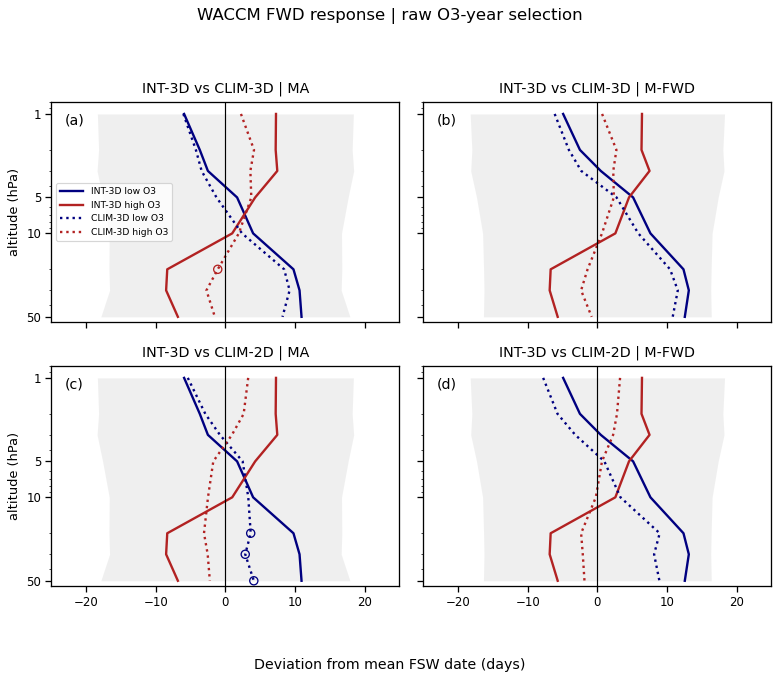

saved: /home/weiji/restart_exam/code_cleaned/Longrun/Visualization/plots/figure2_fwd_response_rm5_o3_4panel.png, /home/weiji/restart_exam/code_cleaned/Longrun/Visualization/plots/figure2_fwd_response_rm5_o3_4panel.svg


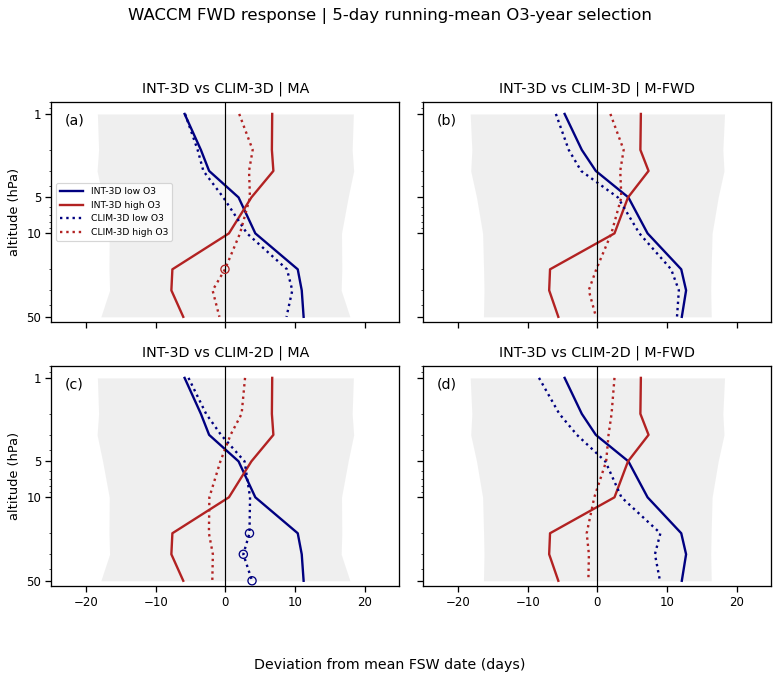

[PosixPath('/home/weiji/restart_exam/code_cleaned/Longrun/Visualization/plots/figure2_fwd_response_rm5_o3_4panel.png'),
 PosixPath('/home/weiji/restart_exam/code_cleaned/Longrun/Visualization/plots/figure2_fwd_response_rm5_o3_4panel.svg')]

In [21]:
fwd_profiles_raw_o3 = load_profiles_by_window(rolling_days=None)
fig_fwd_raw_o3_4panel, _ = plot_waccm_four_panel_group(
    fwd_profiles_raw_o3,
    'WACCM FWD response | raw O3-year selection',
)
save_and_show(fig_fwd_raw_o3_4panel, 'figure2_fwd_response_raw_o3_4panel')

fwd_profiles_5day_o3 = load_profiles_by_window(rolling_days=5)
fig_fwd_5day_o3_4panel, _ = plot_waccm_four_panel_group(
    fwd_profiles_5day_o3,
    'WACCM FWD response | 5-day running-mean O3-year selection',
)
save_and_show(fig_fwd_5day_o3_4panel, 'figure2_fwd_response_rm5_o3_4panel')


## Figures 8 and 9: Wind and EPF Divergence

Figure 8 uses high-ozone springs; Figure 9 uses low-ozone springs. EPFDIV follows the paper plotting logic as an absolute composite of `div1 + div2` with 30-day running mean.


In [ ]:
# ============================================================
# Friedel Fig.-8-style diagnostic from our timefixed climatologies
# ============================================================
# Friedel et al. Fig. 8 uses high-ozone springs, absolute wind composites,
# and absolute EP-flux divergence composites with a 30-day running mean.
# Here EPFDIV is div1 + div2 from our aostools EP-flux files.

FIG8_ROOT = "/mnt/soclim0/public_data/weiji"
FIG8_CASES = {
    "BWCN": os.path.join(FIG8_ROOT, "BWCN", "climatology"),
    "B2000WCN": os.path.join(FIG8_ROOT, "B2000WCN001002_timefixed", "climatology"),
    "INT-3D": {"components": ["BWCN", "B2000WCN"]},
    "CLIM-3D": os.path.join(FIG8_ROOT, "B2000WCN007009010011_Clim3D_timefixed", "climatology"),
    "CLIM-2D": os.path.join(FIG8_ROOT, "B2000WCN_NOCOUPL001002_timefixed", "climatology"),
}

FIG8_EPFLUX_VARIANTS = {
    "legacy": {
        "label": "no DO_UBAR / no omega correction",
        "daily_subdir": "EPflux_daily",
        "clim_subdir": "climatology",
        "stem_suffix": "no_doubar",
    },
    "ubar_wcorr": {
        "label": "DO_UBAR + omega correction",
        "daily_subdir": "EPflux_daily_ubar_wcorr",
        "clim_subdir": "climatology_ubar_wcorr",
        "stem_suffix": "doubar_omega",
    },
}
DEFAULT_FIG8_EPFLUX_VARIANT = "legacy"
FIG8_COMPARISONS = [
    ("INT-3D", "CLIM-3D"),
    ("INT-3D", "CLIM-2D"),
]
FIG8_SAMPLE = "high25_rm5"  # Fig. 8-style high-ozone sample after Climatology writes raw/rm5 extremes
FIG8_LAT_BAND = (55.0, 75.0)
FIG8_PLEV_RANGE_HPA = (1.0, 1000.0)
FIG8_DOY_SLICE = slice(59, 151)  # Mar 1 to May 31 in no-leap, matching the paper March-May range
FIG8_XTICKS = [0, 31, 61, 91]
FIG8_XTICK_LABELS = ["Mar", "Apr", "May", "June"]
FIG8_PLEV_TICKS = [1000, 100, 10, 1]
FIG8_ROLLING_DAYS_EPFDIV = 30
FIG8_EPFDIV_COMPONENTS = ("div1_all_waves", "div2_all_waves")  # total EPF divergence
FIG8_EPFDIV_USE_SAMPLE_MINUS_ALL = False  # Paper-style panels use absolute EPFDIV composites, not sample-minus-all anomalies
FIG8_EPFDIV_SCALE = 1.0  # our div1/div2 files are already in m s^-1 d^-1
FIG8_SAVE = False
FIG8_OUT = str(PLOT_DIR)
FIG8_O3_PRESSURE_TAG = "30_70hPa"
FIG8_O3_VALID_MIN_DU = 10.0
FIG8_O3_STAR_WINDOW_DOY = (60, 120)  # Mar 1-Apr 30, same MA ozone-ranking window
FIG8_DRAW_O3_STAR = True
FIG8_STAR_PRESSURE_HPA = 50.0
FIG8_O3_RANKING_CSVS = {
    "BWCN": os.path.join(FIG8_ROOT, "BWCN", "partial_O3", "BWCN_partial_O3_ranking_MarApr_min_60_90N.csv"),
    "B2000WCN": os.path.join(FIG8_ROOT, "B2000WCN001002_timefixed", "partial_O3", "B2000WCN_partial_O3_ranking_MarApr_min_60_90N.csv"),
    "CLIM-3D": os.path.join(FIG8_ROOT, "B2000WCN007009010011_Clim3D_timefixed", "partial_O3", "B2000WCN007009010011_Clim3D_partial_O3_ranking_MarApr_min_60_90N.csv"),
    "CLIM-2D": os.path.join(FIG8_ROOT, "B2000WCN_NOCOUPL001002_timefixed", "partial_O3", "B2000WCN_NOCOUPL_partial_O3_ranking_MarApr_min_60_90N.csv"),
}
FIG8_O3_PARTIAL_NCS = {
    "BWCN": os.path.join(FIG8_ROOT, "BWCN", "partial_O3", "BWCN_partial_O3_all_ranges.nc"),
    "B2000WCN": os.path.join(FIG8_ROOT, "B2000WCN001002_timefixed", "partial_O3", "B2000WCN_partial_O3_all_ranges.nc"),
    "CLIM-3D": os.path.join(FIG8_ROOT, "B2000WCN007009010011_Clim3D_timefixed", "partial_O3", "B2000WCN007009010011_Clim3D_partial_O3_all_ranges.nc"),
    "CLIM-2D": os.path.join(FIG8_ROOT, "B2000WCN_NOCOUPL001002_timefixed", "partial_O3", "B2000WCN_NOCOUPL_partial_O3_all_ranges.nc"),
}


FIG8_U_ABS_LEVELS = np.linspace(-30.0, 30.0, 25)
FIG8_U_DIFF_LEVELS = np.linspace(-10.0, 10.0, 21)
FIG8_EPFDIV_LEVELS = np.linspace(-2.0, 2.0, 21)

mpl.rc("xtick", direction="out", labelsize=9)
mpl.rc("ytick", direction="out", labelsize=9)
mpl.rc("axes", titlesize=11, labelsize=10)
mpl.rc("font", family="sans-serif")


def fig8_normalize_plev_to_hpa(da):
    p = np.asarray(da["plev"].values, dtype=float)
    p_hpa = p / 100.0 if np.nanmax(np.abs(p)) > 1000.0 else p
    return da.assign_coords(plev=p_hpa)


def fig8_select_lat_band(da, lat_band=FIG8_LAT_BAND):
    lat_min, lat_max = lat_band
    lat_vals = np.asarray(da["lat"].values, dtype=float)
    if lat_vals[0] <= lat_vals[-1]:
        return da.sel(lat=slice(lat_min, lat_max))
    return da.sel(lat=slice(lat_max, lat_min))


def fig8_lat_weighted_mean(da, lat_band=FIG8_LAT_BAND):
    da = fig8_select_lat_band(da, lat_band=lat_band)
    weights = np.cos(np.deg2rad(da["lat"]))
    return da.weighted(weights).mean("lat")


def fig8_common_reduce(da):
    da = fig8_normalize_plev_to_hpa(da)
    lo, hi = FIG8_PLEV_RANGE_HPA
    da = da.where((da["plev"] >= lo) & (da["plev"] <= hi), drop=True)
    da = da.isel(doy=FIG8_DOY_SLICE)
    da = da.assign_coords(plot_day=("doy", np.arange(da.sizes["doy"], dtype=int)))
    out = da.swap_dims({"doy": "plot_day"})
    if "doy" in out.coords:
        out = out.drop_vars("doy")
    return out.transpose("plev", "plot_day")


def fig8_var_name(ds, stem, sample):
    name = f"{stem}_clim_{sample}"
    if name not in ds.data_vars:
        available = sorted(v for v in ds.data_vars if v.startswith(f"{stem}_clim_"))
        raise KeyError(f"{name} not found. Available for {stem}: {available}")
    return name


def fig8_is_composite_case(case_label):
    return isinstance(FIG8_CASES[case_label], dict) and "components" in FIG8_CASES[case_label]


def fig8_case_components(case_label):
    return FIG8_CASES[case_label].get("components", [case_label]) if fig8_is_composite_case(case_label) else [case_label]


def fig8_case_root(case_label):
    root = FIG8_CASES[case_label]
    if isinstance(root, dict):
        raise ValueError(f"{case_label} is a composite case and has no direct root")
    return root


def fig8_case_base_dir(case_label):
    return os.path.dirname(fig8_case_root(case_label))


def fig8_epflux_variant_label(epflux_variant=DEFAULT_FIG8_EPFLUX_VARIANT):
    return FIG8_EPFLUX_VARIANTS[epflux_variant]["label"]


def fig8_epflux_clim_path(case_label, epflux_variant=DEFAULT_FIG8_EPFLUX_VARIANT):
    cfg = FIG8_EPFLUX_VARIANTS[epflux_variant]
    root = os.path.join(fig8_case_base_dir(case_label), cfg["clim_subdir"])
    return os.path.join(root, "EPFLUX_climatology_plev_doy.nc")


def fig8_epflux_daily_path(case_label, epflux_variant=DEFAULT_FIG8_EPFLUX_VARIANT):
    cfg = FIG8_EPFLUX_VARIANTS[epflux_variant]
    pattern = os.path.join(
        fig8_case_base_dir(case_label),
        cfg["daily_subdir"],
        "all_waves",
        "EPFLUX_all_waves_*yr_time_plev_lat.nc",
    )
    matches = sorted(Path(fig8_case_base_dir(case_label)).glob(
        os.path.join(cfg["daily_subdir"], "all_waves", "EPFLUX_all_waves_*yr_time_plev_lat.nc")
    ))
    if not matches:
        return pattern
    return str(matches[-1])


def fig8_sample_flag(sample):
    method = "rm5" if sample.endswith("_rm5") else "raw"
    if sample.startswith("low"):
        return f"is_lowest25pct_{method}"
    if sample.startswith("high"):
        return f"is_highest25pct_{method}"
    return None


def fig8_sample_count(case_label, sample):
    if fig8_is_composite_case(case_label):
        return sum(fig8_sample_count(component, sample) for component in fig8_case_components(case_label))
    csv_path = FIG8_O3_RANKING_CSVS.get(case_label)
    if not csv_path or not os.path.exists(csv_path):
        return 1
    df = pd.read_csv(csv_path)
    if "pressure_range" in df.columns:
        df = df[df["pressure_range"].astype(str) == FIG8_O3_PRESSURE_TAG]
    flag = fig8_sample_flag(sample)
    if flag is None or flag not in df.columns:
        return int(df["year"].nunique())
    return int(df[flag].astype(bool).sum())


def fig8_load_u(case_label, sample):
    if fig8_is_composite_case(case_label):
        pieces = []
        weights = []
        for component in fig8_case_components(case_label):
            pieces.append(fig8_load_u(component, sample))
            weights.append(fig8_sample_count(component, sample))
        aligned = xr.align(*pieces, join="inner")
        total_weight = float(np.sum(weights))
        return sum(da * (w / total_weight) for da, w in zip(aligned, weights))

    path = os.path.join(fig8_case_root(case_label), "U_climatology_plev_doy.nc")
    with xr.open_dataset(path, decode_times=False) as ds:
        name = fig8_var_name(ds, "U", sample)
        da = ds[name]
        if "lon" in da.dims:
            da = da.mean("lon", skipna=True)
        da = fig8_lat_weighted_mean(da)
        da = fig8_common_reduce(da).load()
    da.attrs["source_path"] = path
    da.attrs["source_var"] = name
    return da


def fig8_epfdiv_total(ds, sample):
    pieces = []
    missing = []
    for stem in FIG8_EPFDIV_COMPONENTS:
        name = f"{stem}_clim_{sample}"
        if name in ds.data_vars:
            pieces.append(ds[name])
        else:
            missing.append(name)
    if missing:
        available = sorted(v for v in ds.data_vars if "div" in v and v.endswith(f"clim_{sample}"))
        raise KeyError(f"Missing EPFDIV components {missing}. Available div vars for sample={sample}: {available}")
    total = pieces[0]
    for piece in pieces[1:]:
        total = total + piece
    total.name = f"sum({' + '.join(FIG8_EPFDIV_COMPONENTS)})_clim_{sample}"
    return total


def fig8_dataset_div_pair(ds):
    pairs = [
        ("div1_all_waves", "div2_all_waves"),
        ("div1", "div2"),
        ("div1_all", "div2_all"),
    ]
    for a, b in pairs:
        if a in ds.data_vars and b in ds.data_vars:
            return ds[a] + ds[b], (a, b)
    available = sorted(v for v in ds.data_vars if "div" in v.lower())
    raise KeyError(f"Cannot find EPFDIV pair in dataset. Available div-like vars: {available}")


def fig8_load_epfdiv_from_clim(path, sample):
    with xr.open_dataset(path, decode_times=False) as ds:
        da = fig8_epfdiv_total(ds, sample)
        if FIG8_EPFDIV_USE_SAMPLE_MINUS_ALL and sample != "all":
            da = da - fig8_epfdiv_total(ds, "all")
            da.name = f"EPFDIV_{sample}_minus_all"
        da = da * FIG8_EPFDIV_SCALE
        da = fig8_lat_weighted_mean(da)
        if FIG8_ROLLING_DAYS_EPFDIV and FIG8_ROLLING_DAYS_EPFDIV > 1:
            da = da.rolling(doy=FIG8_ROLLING_DAYS_EPFDIV, center=True, min_periods=max(3, FIG8_ROLLING_DAYS_EPFDIV // 3)).mean()
        da = fig8_common_reduce(da).load()
    da.attrs["source_path"] = path
    da.attrs["source_var"] = da.name or "EPFDIV"
    da.attrs["source_kind"] = "precomputed_climatology"
    return da


def fig8_sample_years_for_daily(case_label, sample):
    if sample == "all":
        return None
    years = fig8_o3_extreme_years(case_label, sample)
    if not years:
        raise ValueError(f"No ozone-ranked years found for {case_label} sample={sample}")
    return np.asarray(years, dtype=int)


def fig8_daily_epfdiv_climatology(case_label, sample, epflux_variant=DEFAULT_FIG8_EPFLUX_VARIANT):
    path = fig8_epflux_daily_path(case_label, epflux_variant)
    if not os.path.exists(path):
        raise FileNotFoundError(path)

    sample_years = fig8_sample_years_for_daily(case_label, sample)
    with xr.open_dataset(path, decode_times=False) as ds:
        da, div_names = fig8_dataset_div_pair(ds)
        years, doys = fig8_calendar_from_time(ds["time"].values)
        da = da.assign_coords(
            model_year=("time", years.astype(int)),
            model_doy=("time", doys.astype(int)),
        )
        if sample_years is not None:
            da = da.where(da["model_year"].isin(sample_years), drop=True)
        if da.sizes.get("time", 0) == 0:
            raise ValueError(f"No EPFDIV timesteps selected for {case_label} sample={sample} variant={epflux_variant}")
        da = da.groupby("model_doy").mean("time", skipna=True).rename({"model_doy": "doy"})
        da.name = f"daily_{'+'.join(div_names)}_clim_{sample}"
        da = da.load()

    return da, path


def fig8_load_epfdiv_from_daily(case_label, sample, epflux_variant=DEFAULT_FIG8_EPFLUX_VARIANT):
    da, path = fig8_daily_epfdiv_climatology(case_label, sample, epflux_variant=epflux_variant)
    if FIG8_EPFDIV_USE_SAMPLE_MINUS_ALL and sample != "all":
        da_all, _ = fig8_daily_epfdiv_climatology(case_label, "all", epflux_variant=epflux_variant)
        da = da - da_all
        da.name = f"EPFDIV_{sample}_minus_all_from_daily"
    da = da * FIG8_EPFDIV_SCALE
    da = fig8_lat_weighted_mean(da)
    if FIG8_ROLLING_DAYS_EPFDIV and FIG8_ROLLING_DAYS_EPFDIV > 1:
        da = da.rolling(doy=FIG8_ROLLING_DAYS_EPFDIV, center=True, min_periods=max(3, FIG8_ROLLING_DAYS_EPFDIV // 3)).mean()
    da = fig8_common_reduce(da).load()
    da.attrs["source_path"] = path
    da.attrs["source_var"] = da.name or "EPFDIV"
    da.attrs["source_kind"] = "daily_epflux_on_the_fly_climatology"
    return da


def fig8_precomputed_epfdiv_available(path, sample):
    if not os.path.exists(path):
        return False
    try:
        with xr.open_dataset(path, decode_times=False) as ds:
            return all(f"{stem}_clim_{sample}" in ds.data_vars for stem in FIG8_EPFDIV_COMPONENTS)
    except Exception:
        return False


def fig8_load_epfdiv(case_label, sample, epflux_variant=DEFAULT_FIG8_EPFLUX_VARIANT):
    if fig8_is_composite_case(case_label):
        pieces = []
        weights = []
        for component in fig8_case_components(case_label):
            pieces.append(fig8_load_epfdiv(component, sample, epflux_variant=epflux_variant))
            weights.append(fig8_sample_count(component, sample))
        aligned = xr.align(*pieces, join="inner")
        total_weight = float(np.sum(weights))
        return sum(da * (w / total_weight) for da, w in zip(aligned, weights))

    clim_path = fig8_epflux_clim_path(case_label, epflux_variant)
    if fig8_precomputed_epfdiv_available(clim_path, sample):
        return fig8_load_epfdiv_from_clim(clim_path, sample)
    return fig8_load_epfdiv_from_daily(case_label, sample, epflux_variant=epflux_variant)


def fig8_daily_epfdiv_available(case_label, sample, epflux_variant=DEFAULT_FIG8_EPFLUX_VARIANT):
    if fig8_is_composite_case(case_label):
        return all(
            fig8_daily_epfdiv_available(component, sample, epflux_variant=epflux_variant)
            for component in fig8_case_components(case_label)
        )
    path = fig8_epflux_daily_path(case_label, epflux_variant)
    if not os.path.exists(path):
        return False
    if sample != "all" and not fig8_o3_extreme_years(case_label, sample):
        return False
    return True


def fig8_check_one_sample_availability(case_label, sample, epflux_variant=DEFAULT_FIG8_EPFLUX_VARIANT):
    if fig8_is_composite_case(case_label):
        child = [
            fig8_check_one_sample_availability(component, sample, epflux_variant=epflux_variant)
            for component in fig8_case_components(case_label)
        ]
        return {
            "case": case_label,
            "U_sample_ok": all(row["U_sample_ok"] for row in child),
            "EPFDIV_sample_ok": all(row["EPFDIV_sample_ok"] for row in child),
            "EPFDIV_source": "+".join(row["EPFDIV_source"] for row in child),
        }
    u_path = os.path.join(fig8_case_root(case_label), "U_climatology_plev_doy.nc")
    ep_clim_path = fig8_epflux_clim_path(case_label, epflux_variant)
    with xr.open_dataset(u_path, decode_times=False) as ds_u:
        u_ok = f"U_clim_{sample}" in ds_u.data_vars
    if fig8_precomputed_epfdiv_available(ep_clim_path, sample):
        ep_ok = True
        ep_source = "precomputed_climatology"
    else:
        ep_ok = fig8_daily_epfdiv_available(case_label, sample, epflux_variant=epflux_variant)
        ep_source = "daily_epflux_on_the_fly" if ep_ok else "missing"
    return {"case": case_label, "U_sample_ok": u_ok, "EPFDIV_sample_ok": ep_ok, "EPFDIV_source": ep_source}


def fig8_check_sample_availability(sample, epflux_variant=DEFAULT_FIG8_EPFLUX_VARIANT):
    rows = []
    for case_label in ["INT-3D", "CLIM-3D", "CLIM-2D"]:
        row = fig8_check_one_sample_availability(case_label, sample, epflux_variant=epflux_variant)
        rows.append({
            "case": case_label,
            "EP_flux_variant": epflux_variant,
            "EP_flux_label": fig8_epflux_variant_label(epflux_variant),
            "U_sample_ok": bool(row["U_sample_ok"]),
            "U_available_samples": "combined" if fig8_is_composite_case(case_label) else "direct",
            "EPFDIV_sample_ok": bool(row["EPFDIV_sample_ok"]),
            "EPFDIV_source": row.get("EPFDIV_source", "unknown"),
        })
    return pd.DataFrame(rows)


def fig8_format_axis(ax, show_xlabel=False, show_ylabel=False):
    # Plot log(pressure) as the coordinate, with manual pressure labels.
    lo, hi = FIG8_PLEV_RANGE_HPA
    ax.set_ylim(np.log(hi), np.log(lo))
    ticks = np.asarray(FIG8_PLEV_TICKS, dtype=float)
    ax.set_yticks(np.log(ticks))
    ax.set_yticklabels([f"{int(t):d}" for t in ticks])
    ax.set_xlim(0, FIG8_DOY_SLICE.stop - FIG8_DOY_SLICE.start - 1)
    ax.set_xticks(FIG8_XTICKS)
    ax.set_xticklabels(FIG8_XTICK_LABELS)
    ax.grid(False)
    if show_ylabel:
        ax.set_ylabel("pressure (hPa)")
    if show_xlabel:
        ax.set_xlabel("")


def fig8_panel(ax, da, levels, cmap, title=None, zero=True, label=None):
    x = da["plot_day"].values
    p = da["plev"].values.astype(float)
    y = np.log(p)
    z = da.values.astype(float)
    cf = ax.contourf(x, y, z, levels=levels, cmap=plt.cm.get_cmap(cmap), extend="both")
    if zero:
        try:
            ax.contour(x, y, z, levels=[0.0], colors="0.35", linewidths=0.8)
        except Exception:
            pass
    if title:
        ax.set_title(title, fontsize=12)
    if label:
        ax.text(
            0.06, 0.86, label,
            transform=ax.transAxes, fontsize=11,
            bbox=dict(facecolor="white", edgecolor="0.85", alpha=0.95, pad=2.0),
        )
    return cf


def fig8_date_to_doy_no_leap(date_values):
    date_values = np.asarray(date_values, dtype=np.int64)
    mmdd = date_values % 10000
    month = (mmdd // 100).astype(np.int16)
    day = (mmdd % 100).astype(np.int16)
    month_ends = np.array([31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334, 365])
    doy = np.full(date_values.shape, -9999, dtype=np.int16)
    for m in range(1, 13):
        mask = month == m
        if np.any(mask):
            prev = int(month_ends[m - 2]) if m > 1 else 0
            doy[mask] = prev + day[mask]
    return doy.astype(int)


def fig8_calendar_from_time(time_values):
    day_index = np.asarray(time_values, dtype=float).astype(np.int64)
    year = day_index // 365 + 1
    doy = day_index % 365 + 1
    return year.astype(int), doy.astype(int)


def fig8_partial_o3_calendar(ds):
    if "date" in ds:
        dates = ds["date"].values.astype(np.int64)
        return (dates // 10000).astype(int), fig8_date_to_doy_no_leap(dates)
    return fig8_calendar_from_time(ds["time"].values)


def fig8_o3_partial_var(ds):
    direct = f"O3_partial_60_90N_{FIG8_O3_PRESSURE_TAG}"
    if direct in ds.data_vars:
        return ds[direct]
    if "O3_partial_60_90N" in ds.data_vars:
        return ds["O3_partial_60_90N"].sel(pressure_range=FIG8_O3_PRESSURE_TAG)
    candidates = [v for v in ds.data_vars if v.startswith("O3_partial_60_90N")]
    raise KeyError(f"Cannot find partial O3 variable for {FIG8_O3_PRESSURE_TAG}. Candidates: {candidates}")


def fig8_o3_extreme_years(case_label, sample):
    method = "rm5" if sample.endswith("_rm5") else "raw"
    if sample.startswith("high"):
        flag = f"is_highest25pct_{method}"
    elif sample.startswith("low"):
        flag = f"is_lowest25pct_{method}"
    else:
        return []

    csv_path = FIG8_O3_RANKING_CSVS.get(case_label)
    if not csv_path or not os.path.exists(csv_path):
        return []
    df = pd.read_csv(csv_path)
    if "pressure_range" in df.columns:
        df = df[df["pressure_range"].astype(str) == FIG8_O3_PRESSURE_TAG]
    if flag not in df.columns:
        return []
    return sorted(df.loc[df[flag].astype(bool), "year"].astype(int).unique().tolist())


def fig8_o3_extreme_star_day(case_label, sample):
    if not FIG8_DRAW_O3_STAR:
        return None
    if fig8_is_composite_case(case_label):
        days = [fig8_o3_extreme_star_day(component, sample) for component in fig8_case_components(case_label)]
        days = [day for day in days if day is not None and np.isfinite(day)]
        return None if not days else float(np.nanmean(days))

    years = fig8_o3_extreme_years(case_label, sample)
    if not years:
        return None
    nc_path = FIG8_O3_PARTIAL_NCS.get(case_label)
    if not nc_path or not os.path.exists(nc_path):
        return None

    method = "rm5" if sample.endswith("_rm5") else "raw"
    want_high = sample.startswith("high")
    start_doy, end_doy = FIG8_O3_STAR_WINDOW_DOY

    with xr.open_dataset(nc_path, decode_times=False) as ds:
        da = fig8_o3_partial_var(ds).load()
        year_arr, doy_arr = fig8_partial_o3_calendar(ds)

    vals = np.asarray(da.values, dtype=float)
    vals = np.where(vals > FIG8_O3_VALID_MIN_DU, vals, np.nan)
    if method == "rm5":
        vals = pd.Series(vals).rolling(window=5, center=True, min_periods=5).mean().to_numpy()

    event_days = []
    for y in years:
        mask = (year_arr == y) & (doy_arr >= start_doy) & (doy_arr <= end_doy) & np.isfinite(vals)
        if not np.any(mask):
            continue
        sub_vals = vals[mask]
        sub_doy = doy_arr[mask]
        idx = int(np.nanargmax(sub_vals) if want_high else np.nanargmin(sub_vals))
        event_days.append(float(sub_doy[idx] - start_doy))

    if not event_days:
        return None
    return float(np.nanmean(event_days))


def fig8_draw_star(ax, x_day, p_hpa=FIG8_STAR_PRESSURE_HPA):
    if x_day is None or not np.isfinite(x_day):
        return
    ax.plot(
        x_day, np.log(float(p_hpa)), marker="*", markersize=14,
        color="white", markeredgecolor="black", markeredgewidth=0.8,
        linestyle="None", zorder=8,
    )


def plot_fig8_style_wind_epfdiv(sample=FIG8_SAMPLE, epflux_variant=DEFAULT_FIG8_EPFLUX_VARIANT):
    availability = fig8_check_sample_availability(sample, epflux_variant=epflux_variant)
    if not availability[["U_sample_ok", "EPFDIV_sample_ok"]].to_numpy().all():
        raise KeyError(
            f"Requested sample={sample!r}, epflux_variant={epflux_variant!r} is not available for all cases. "
            "Need U climatology samples plus either EPFLUX climatology samples or daily EP flux files."
        )

    nrow = len(FIG8_COMPARISONS)
    ncol = 4
    fig, axes = plt.subplots(
        nrow, ncol, figsize=(2.35 * ncol + 0.8, 3.05 * nrow + 0.8),
        sharex=True, sharey=True, constrained_layout=True,
    )
    if nrow == 1:
        axes = np.asarray([axes])

    cf_abs = cf_wdiff = cf_ep = None
    letters = iter("abcdefghijklmnopqrstuvwxyz")
    stats_rows = []

    for i, (case_a, case_b) in enumerate(FIG8_COMPARISONS):
        u_a = fig8_load_u(case_a, sample)
        u_b = fig8_load_u(case_b, sample)
        u_a, u_b = xr.align(u_a, u_b, join="inner")
        u_diff = (u_a - u_b).load()

        ep_a = fig8_load_epfdiv(case_a, sample, epflux_variant=epflux_variant)
        ep_b = fig8_load_epfdiv(case_b, sample, epflux_variant=epflux_variant)
        ep_a, ep_b = xr.align(ep_a, ep_b, join="inner")
        ep_diff = (ep_a - ep_b).load()

        row_label = f"{case_a} - {case_b}"
        star_day = fig8_o3_extreme_star_day(case_a, sample)
        panels = [
            (u_a, FIG8_U_ABS_LEVELS, "seismic", f"{case_a}\\nAbsolute wind", True, "m s$^{-1}$"),
            (u_b, FIG8_U_ABS_LEVELS, "seismic", f"{case_b}\\nAbsolute wind", True, "m s$^{-1}$"),
            (u_diff, FIG8_U_DIFF_LEVELS, "seismic", "Wind difference", True, "m s$^{-1}$"),
            (ep_diff, FIG8_EPFDIV_LEVELS, "seismic", "Difference in\\nEPF divergence", True, "m s$^{-1}$ d$^{-1}$"),
        ]

        for j, (da, levels, cmap, title, zero, units) in enumerate(panels):
            ax = axes[i, j]
            cf = fig8_panel(ax, da, levels=levels, cmap=cmap, title=title if i == 0 else None, zero=zero, label=f"({next(letters)})")
            fig8_format_axis(ax, show_xlabel=(i == nrow - 1), show_ylabel=(j == 0))
            if j == 0:
                ax.text(-0.42, 0.5, row_label, rotation=90, transform=ax.transAxes, ha="center", va="center", fontsize=11)
            if j >= 2:
                fig8_draw_star(ax, star_day)
            if j in [0, 1]:
                cf_abs = cf
            elif j == 2:
                cf_wdiff = cf
            else:
                cf_ep = cf

        stats_rows.append({
            "comparison": row_label,
            "sample": sample,
            "EP_flux_variant": epflux_variant,
            "EP_flux_label": fig8_epflux_variant_label(epflux_variant),
            "lat_band": f"{FIG8_LAT_BAND[0]:g}-{FIG8_LAT_BAND[1]:g}N",
            "o3_star_day_from_mar1": np.nan if star_day is None else star_day,
            "u_diff_mean": float(np.nanmean(u_diff.values)),
            "u_diff_mae": float(np.nanmean(np.abs(u_diff.values))),
            "u_diff_max_abs": float(np.nanmax(np.abs(u_diff.values))),
            "epfdiv_diff_mean": float(np.nanmean(ep_diff.values)),
            "epfdiv_diff_mae": float(np.nanmean(np.abs(ep_diff.values))),
            "epfdiv_diff_max_abs": float(np.nanmax(np.abs(ep_diff.values))),
        })

    cbar_abs = fig.colorbar(cf_abs, ax=axes[:, 0:2], orientation="horizontal", pad=0.08, fraction=0.06, aspect=35)
    cbar_abs.set_label("m s$^{-1}$")
    cbar_diff = fig.colorbar(cf_wdiff, ax=axes[:, 2], orientation="horizontal", pad=0.08, fraction=0.06, aspect=18)
    cbar_diff.set_label("m s$^{-1}$")
    cbar_ep = fig.colorbar(cf_ep, ax=axes[:, 3], orientation="horizontal", pad=0.08, fraction=0.06, aspect=18)
    cbar_ep.set_label("m s$^{-1}$ d$^{-1}$")

    ep_note = "sample-minus-all anomalies" if FIG8_EPFDIV_USE_SAMPLE_MINUS_ALL and sample != "all" else "paper-style absolute sample composite"
    fig.suptitle(
        f"Wind and EPF divergence in {sample} springs ({FIG8_LAT_BAND[0]:.0f}-{FIG8_LAT_BAND[1]:.0f}N; EP flux: {fig8_epflux_variant_label(epflux_variant)}; EPFDIV: {ep_note}, {FIG8_ROLLING_DAYS_EPFDIV} d running mean)",
        fontsize=13,
        y=1.02,
    )

    stats = pd.DataFrame(stats_rows)
    return fig, stats


In [ ]:
fig8_epflux_plot_outputs = {}
for _epflux_variant, _cfg in FIG8_EPFLUX_VARIANTS.items():
    _availability_high = fig8_check_sample_availability('high25_rm5', epflux_variant=_epflux_variant)
    print(f"Figure 8 availability | EP flux={_cfg['label']}")
    display(_availability_high)
    if _availability_high[["U_sample_ok", "EPFDIV_sample_ok"]].to_numpy().all():
        fig8_high, fig8_high_stats = plot_fig8_style_wind_epfdiv('high25_rm5', epflux_variant=_epflux_variant)
        save_and_show(fig8_high, f"figure8_high_ozone_wind_epfdiv_rm5_{_cfg['stem_suffix']}")
        fig8_epflux_plot_outputs[("high25_rm5", _epflux_variant)] = fig8_high_stats
    else:
        print(f"Skip Figure 8 high25_rm5 for EP flux variant {_epflux_variant!r}")

    _availability_low = fig8_check_sample_availability('low25_rm5', epflux_variant=_epflux_variant)
    print(f"Figure 9 availability | EP flux={_cfg['label']}")
    display(_availability_low)
    if _availability_low[["U_sample_ok", "EPFDIV_sample_ok"]].to_numpy().all():
        fig9_low, fig9_low_stats = plot_fig8_style_wind_epfdiv('low25_rm5', epflux_variant=_epflux_variant)
        save_and_show(fig9_low, f"figure9_low_ozone_wind_epfdiv_rm5_{_cfg['stem_suffix']}")
        fig8_epflux_plot_outputs[("low25_rm5", _epflux_variant)] = fig9_low_stats
    else:
        print(f"Skip Figure 9 low25_rm5 for EP flux variant {_epflux_variant!r}")


## Shared Helpers for Appendix Figures


In [24]:
ROOT = '/mnt/soclim0/public_data/weiji'
CASES = {
    'BWCN': {
        'root': f'{ROOT}/BWCN',
        'prefix': 'BWCN',
        'ranking_csv': f'{ROOT}/BWCN/partial_O3/BWCN_partial_O3_ranking_MarApr_min_60_90N.csv',
        'partial_o3_nc': f'{ROOT}/BWCN/partial_O3/BWCN_partial_O3_all_ranges.nc',
        'ao_csv': f'{ROOT}/BWCN/NAM/BWCN_Daily_AO_Index.csv',
        'ehf_nc': f'{ROOT}/BWCN/Eddyheatflux_daily/EHF_BWCN_vTprime_24yr_time_plev_lat.nc',
    },
    'B2000WCN': {
        'root': f'{ROOT}/B2000WCN001002_timefixed',
        'prefix': 'B2000WCN001002',
        'ranking_csv': f'{ROOT}/B2000WCN001002_timefixed/partial_O3/B2000WCN_partial_O3_ranking_MarApr_min_60_90N.csv',
        'partial_o3_nc': f'{ROOT}/B2000WCN001002_timefixed/partial_O3/B2000WCN_partial_O3_all_ranges.nc',
        'ao_csv': f'{ROOT}/B2000WCN001002_timefixed/NAM/B2000WCN001002_Daily_AO_Index.csv',
        'ehf_nc': f'{ROOT}/B2000WCN001002_timefixed/Eddyheatflux_daily/EHF_B2000WCN001002_vTprime_210yr_time_plev_lat.nc',
    },
    'INT-3D': {
        'components': ['BWCN', 'B2000WCN'],
        'prefix': 'INT-3D',
    },
    'CLIM-3D': {
        'root': f'{ROOT}/B2000WCN007009010011_Clim3D_timefixed',
        'prefix': 'B2000WCN007009010011_Clim3D',
        'ranking_csv': f'{ROOT}/B2000WCN007009010011_Clim3D_timefixed/partial_O3/B2000WCN007009010011_Clim3D_partial_O3_ranking_MarApr_min_60_90N.csv',
        'partial_o3_nc': f'{ROOT}/B2000WCN007009010011_Clim3D_timefixed/partial_O3/B2000WCN007009010011_Clim3D_partial_O3_all_ranges.nc',
        'ao_csv': f'{ROOT}/B2000WCN007009010011_Clim3D_timefixed/NAM/B2000WCN007009010011_Clim3D_Daily_AO_Index.csv',
        'ehf_nc': f'{ROOT}/B2000WCN007009010011_Clim3D_timefixed/Eddyheatflux_daily/EHF_B2000WCN007009010011_Clim3D_vTprime_216yr_time_plev_lat.nc',
    },
    'CLIM-2D': {
        'root': f'{ROOT}/B2000WCN_NOCOUPL001002_timefixed',
        'prefix': 'B2000WCN_NOCOUPL001002',
        'ranking_csv': f'{ROOT}/B2000WCN_NOCOUPL001002_timefixed/partial_O3/B2000WCN_NOCOUPL_partial_O3_ranking_MarApr_min_60_90N.csv',
        'partial_o3_nc': f'{ROOT}/B2000WCN_NOCOUPL001002_timefixed/partial_O3/B2000WCN_NOCOUPL_partial_O3_all_ranges.nc',
        'ao_csv': f'{ROOT}/B2000WCN_NOCOUPL001002_timefixed/NAM/B2000WCN_NOCOUPL001002_Daily_AO_Index.csv',
        'ehf_nc': f'{ROOT}/B2000WCN_NOCOUPL001002_timefixed/Eddyheatflux_daily/EHF_B2000WCN_NOCOUPL001002_vTprime_205yr_time_plev_lat.nc',
    },
}
SAMPLE_LOW = 'low25_rm5'
SAMPLE_HIGH = 'high25_rm5'
PRESSURE_TAG = '30_70hPa'
MONTH_ENDS = np.array([31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334, 365])


def case_components(case):
    return CASES[case].get('components', [case])


def is_composite_case(case):
    return 'components' in CASES[case]


def sample_flag(sample):
    method = 'rm5' if sample.endswith('_rm5') else 'raw'
    if sample.startswith('low'):
        return f'is_lowest25pct_{method}'
    if sample.startswith('high'):
        return f'is_highest25pct_{method}'
    return None


def sample_value_col(sample):
    method = 'rm5' if sample.endswith('_rm5') else 'raw'
    if sample.startswith('high'):
        return f'marapr_max_DU_{method}'
    return f'marapr_min_DU_{method}'


def ranking_df(case):
    df = pd.read_csv(CASES[case]['ranking_csv'])
    if 'pressure_range' in df.columns:
        df = df[df['pressure_range'].astype(str) == PRESSURE_TAG].copy()
    df['year'] = df['year'].astype(int)
    return df


def case_sample_count(case, sample):
    if is_composite_case(case):
        return sum(case_sample_count(component, sample) for component in case_components(case))
    df = ranking_df(case)
    flag = sample_flag(sample)
    if flag is None or flag not in df.columns:
        return int(df['year'].nunique())
    return int(df[flag].astype(bool).sum())


def clim_path(case, var):
    return os.path.join(CASES[case]['root'], 'climatology', f'{var}_climatology_plev_doy.nc')


def load_component_clim_da(case, var, sample, stem=None):
    path = clim_path(case, var)
    with xr.open_dataset(path, decode_times=False) as ds:
        name = f'{stem or var}_clim_{sample}'
        if name not in ds:
            raise KeyError(f'{name} not in {path}')
        da = ds[name]
        if 'lon' in da.dims:
            da = da.mean('lon', skipna=True)
        return da.load()


def load_clim_da(case, var, sample, stem=None):
    if not is_composite_case(case):
        return load_component_clim_da(case, var, sample, stem=stem)

    weighted = []
    weights = []
    for component in case_components(case):
        da = load_component_clim_da(component, var, sample, stem=stem)
        weighted.append(da)
        weights.append(case_sample_count(component, sample))
    aligned = xr.align(*weighted, join='inner')
    total_weight = float(np.sum(weights))
    if total_weight <= 0:
        raise ValueError(f'No sample years available for {case} {sample}')
    out = sum(da * (w / total_weight) for da, w in zip(aligned, weights))
    out.attrs['components'] = ','.join(case_components(case))
    out.attrs['weights'] = ','.join(str(w) for w in weights)
    return out


def reduce_time_plev_lat(da, lat_band=(55, 75), plev_range=(1, 1000), doy_slice=slice(59, 151)):
    da = normalize_plev_to_hpa(da)
    da = da.where((da.plev >= plev_range[0]) & (da.plev <= plev_range[1]), drop=True)
    if 'lat' in da.dims:
        da = coslat_weighted_mean(da, lat_band[0], lat_band[1])
    da = da.isel(doy=doy_slice)
    da = da.assign_coords(plot_day=('doy', np.arange(da.sizes['doy'])))
    out = da.swap_dims({'doy': 'plot_day'})
    if 'doy' in out.coords:
        out = out.drop_vars('doy')
    return out.transpose('plev', 'plot_day')


def load_u_section(case, sample, lat_band=(55, 75), plev_range=(1, 1000), doy_slice=slice(59, 151)):
    return reduce_time_plev_lat(load_clim_da(case, 'U', sample), lat_band=lat_band, plev_range=plev_range, doy_slice=doy_slice)


def load_epfdiv_section(case, sample, lat_band=(55, 75), plev_range=(1, 1000), doy_slice=slice(59, 151), rolling=30):
    da = load_clim_da(case, 'EPFLUX', sample, stem='div1_all_waves') + load_clim_da(case, 'EPFLUX', sample, stem='div2_all_waves')
    if rolling:
        da = da.rolling(doy=rolling, center=True, min_periods=max(3, rolling // 3)).mean()
    return reduce_time_plev_lat(da, lat_band=lat_band, plev_range=plev_range, doy_slice=doy_slice)


def plot_logp_panel(ax, da, levels, cmap='seismic', title='', label=''):
    x = da.plot_day.values
    p = da.plev.values.astype(float)
    y = np.log(p)
    cf = ax.contourf(x, y, da.values, levels=levels, cmap=plt.cm.get_cmap(cmap), extend='both')
    try:
        ax.contour(x, y, da.values, levels=[0], colors='0.35', linewidths=0.8)
    except Exception:
        pass
    ax.set_ylim(np.log(1000), np.log(1))
    ticks = np.array([1000, 100, 10, 1])
    ax.set_yticks(np.log(ticks))
    ax.set_yticklabels([str(t) for t in ticks])
    month_ticks_mar_may(ax)
    ax.set_title(title, fontsize=11)
    ax.text(0.06, 0.86, label, transform=ax.transAxes, fontsize=10, bbox=dict(facecolor='white', edgecolor='0.85', pad=2))
    return cf


## Figure A1: 50 hPa Zonal Wind Evolution

Two WACCM-style outputs: INT-3D vs CLIM-3D and INT-3D vs CLIM-2D.


A1 shaded-area check:
  Figure A1 in the paper shades the INT-3D high/low spring standard deviation.
  Current climatology files save sample means and sample counts, but not per-doy std/variance fields.
  BWCN: U spread variables -> not stored
  B2000WCN: U spread variables -> not stored
  CLIM-3D: U spread variables -> not stored
  CLIM-2D: U spread variables -> not stored
  Therefore A1 keeps the mean-line comparison only unless U climatology is regenerated with std fields.
saved: /home/weiji/restart_exam/code_cleaned/Longrun/Visualization/plots/figureA1_waccm_u50_INT3D_vs_CLIM3D_rm5.png, /home/weiji/restart_exam/code_cleaned/Longrun/Visualization/plots/figureA1_waccm_u50_INT3D_vs_CLIM3D_rm5.svg


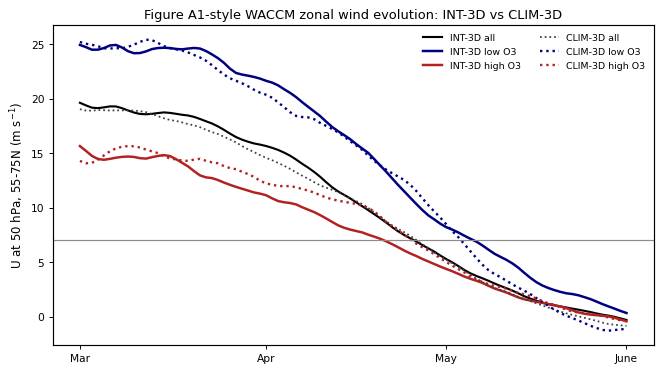

saved: /home/weiji/restart_exam/code_cleaned/Longrun/Visualization/plots/figureA1_waccm_u50_INT3D_vs_CLIM2D_rm5.png, /home/weiji/restart_exam/code_cleaned/Longrun/Visualization/plots/figureA1_waccm_u50_INT3D_vs_CLIM2D_rm5.svg


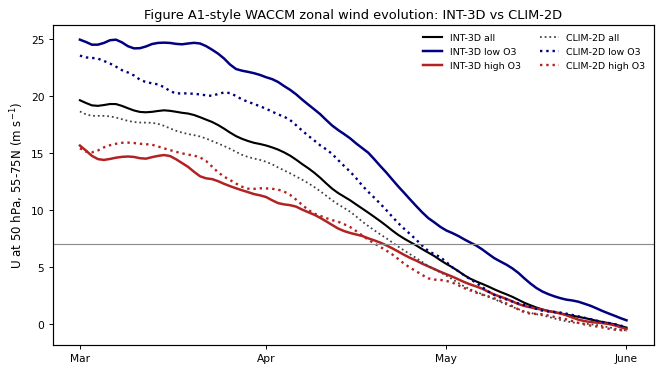

[PosixPath('/home/weiji/restart_exam/code_cleaned/Longrun/Visualization/plots/figureA1_waccm_u50_INT3D_vs_CLIM2D_rm5.png'),
 PosixPath('/home/weiji/restart_exam/code_cleaned/Longrun/Visualization/plots/figureA1_waccm_u50_INT3D_vs_CLIM2D_rm5.svg')]

In [25]:
def climatology_spread_vars(case, var='U'):
    """Return saved spread variables, if the climatology file contains any."""
    if is_composite_case(case):
        out = {}
        for component in case_components(case):
            out[component] = climatology_spread_vars(component, var=var)
        return out
    path = clim_path(case, var)
    with xr.open_dataset(path, decode_times=False) as ds:
        return [
            name for name in ds.data_vars
            if any(token in name.lower() for token in ('std', 'stdev', 'sigma', 'variance'))
        ]


def print_a1_spread_status():
    print('A1 shaded-area check:')
    print('  Figure A1 in the paper shades the INT-3D high/low spring standard deviation.')
    print('  Current climatology files save sample means and sample counts, but not per-doy std/variance fields.')
    for case in ['BWCN', 'B2000WCN', 'CLIM-3D', 'CLIM-2D']:
        spread = climatology_spread_vars(case, var='U')
        status = 'available: ' + ', '.join(spread) if spread else 'not stored'
        print(f'  {case}: U spread variables -> {status}')
    print('  Therefore A1 keeps the mean-line comparison only unless U climatology is regenerated with std fields.')


def load_u50_series(case, sample):
    da = load_clim_da(case, 'U', sample)
    da = select_plev_hpa(da, 50.0)
    da = coslat_weighted_mean(da, 55, 75)
    da = da.isel(doy=slice(59, 151))
    return np.arange(da.sizes['doy']), da.values.astype(float)


def plot_a1_pair(compare_case):
    fig, ax = plt.subplots(figsize=(8.0, 4.6))
    x, int_all = load_u50_series('INT-3D', 'all')
    _, int_low = load_u50_series('INT-3D', SAMPLE_LOW)
    _, int_high = load_u50_series('INT-3D', SAMPLE_HIGH)
    _, cmp_all = load_u50_series(compare_case, 'all')
    _, cmp_low = load_u50_series(compare_case, SAMPLE_LOW)
    _, cmp_high = load_u50_series(compare_case, SAMPLE_HIGH)

    ax.plot(x, int_all, color='k', lw=1.8, label='INT-3D all')
    ax.plot(x, int_low, color='navy', lw=2.1, label='INT-3D low O3')
    ax.plot(x, int_high, color='firebrick', lw=2.1, label='INT-3D high O3')
    ax.plot(x, cmp_all, color='0.25', lw=1.5, ls=':', label=f'{compare_case} all')
    ax.plot(x, cmp_low, color='navy', lw=2.0, ls=':', label=f'{compare_case} low O3')
    ax.plot(x, cmp_high, color='firebrick', lw=2.0, ls=':', label=f'{compare_case} high O3')
    ax.axhline(7, color='0.55', lw=1.0)
    month_ticks_mar_may(ax)
    ax.set_ylabel('U at 50 hPa, 55-75N (m s$^{-1}$)')
    ax.set_title(f'Figure A1-style WACCM zonal wind evolution: INT-3D vs {compare_case}')
    ax.legend(ncol=2, fontsize=8, frameon=False)
    ax.grid(False)
    fig.tight_layout()
    return fig


print_a1_spread_status()
fig_a1_clim3d = plot_a1_pair('CLIM-3D')
save_and_show(fig_a1_clim3d, 'figureA1_waccm_u50_INT3D_vs_CLIM3D_rm5')
fig_a1_clim2d = plot_a1_pair('CLIM-2D')
save_and_show(fig_a1_clim2d, 'figureA1_waccm_u50_INT3D_vs_CLIM2D_rm5')


## Figure A2: INT-3D Arctic Partial-Ozone Evolution


saved: /home/weiji/restart_exam/code_cleaned/Longrun/Visualization/plots/figureA2_waccm_INT3D_partial_o3_rm5.png, /home/weiji/restart_exam/code_cleaned/Longrun/Visualization/plots/figureA2_waccm_INT3D_partial_o3_rm5.svg


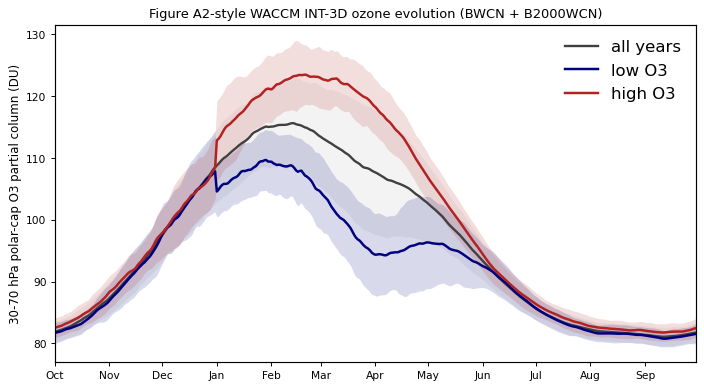

[PosixPath('/home/weiji/restart_exam/code_cleaned/Longrun/Visualization/plots/figureA2_waccm_INT3D_partial_o3_rm5.png'),
 PosixPath('/home/weiji/restart_exam/code_cleaned/Longrun/Visualization/plots/figureA2_waccm_INT3D_partial_o3_rm5.svg')]

In [26]:
def extreme_years(case, sample):
    if is_composite_case(case):
        pieces = []
        for component in case_components(case):
            df = ranking_df(component).copy()
            df['component'] = component
            pieces.append(df)
        df = pd.concat(pieces, ignore_index=True)
        value_col = sample_value_col(sample)
        if value_col not in df.columns:
            raise KeyError(f'{value_col} missing for {case}')
        df['_extreme_value'] = pd.to_numeric(df[value_col], errors='coerce')
        df = df[np.isfinite(df['_extreme_value'])].copy()
        n25 = max(int(0.25 * len(df)), 1)
        if sample.startswith('high'):
            selected = df.nlargest(n25, '_extreme_value')
        else:
            selected = df.nsmallest(n25, '_extreme_value')
        return list(zip(selected['component'].astype(str), selected['year'].astype(int)))

    df = ranking_df(case)
    flag = sample_flag(sample)
    if flag not in df.columns:
        value_col = sample_value_col(sample)
        n25 = max(int(0.25 * len(df)), 1)
        selected = df.nlargest(n25, value_col) if sample.startswith('high') else df.nsmallest(n25, value_col)
        return sorted(selected['year'].astype(int).unique())
    return sorted(df.loc[df[flag].astype(bool), 'year'].astype(int).unique())


def load_partial_o3_matrix(case):
    if is_composite_case(case):
        return pd.concat([load_partial_o3_matrix(component) for component in case_components(case)], ignore_index=True)
    with xr.open_dataset(CASES[case]['partial_o3_nc'], decode_times=False) as ds:
        name = f'O3_partial_60_90N_{PRESSURE_TAG}'
        da = ds[name] if name in ds else ds['O3_partial_60_90N'].sel(pressure_range=PRESSURE_TAG)
        vals = da.load().values.astype(float)
        years, doys = calendar_from_dataset(ds)
    vals = np.where(vals > 10.0, vals, np.nan)
    return pd.DataFrame({'component': case, 'year': years, 'doy': doys, 'o3': vals})


def filter_extreme_df(df, years):
    if years is None:
        return df
    if len(years) == 0:
        return df.iloc[0:0]
    if isinstance(years[0], tuple):
        keys = set((str(component), int(year)) for component, year in years)
        return df[[((str(component), int(year)) in keys) for component, year in zip(df['component'], df['year'])]]
    return df[df.year.isin(years)]


def composite_by_doy(df, years=None, value='o3'):
    d = filter_extreme_df(df, years)
    g = d.groupby('doy')[value]
    return g.mean().reindex(np.arange(1, 366)), g.std().reindex(np.arange(1, 366))


def reorder_oct_sep(series):
    order = np.r_[np.arange(274, 366), np.arange(1, 274)]
    return series.reindex(order).reset_index(drop=True)


partial_df = load_partial_o3_matrix('INT-3D')
low_years = extreme_years('INT-3D', SAMPLE_LOW)
high_years = extreme_years('INT-3D', SAMPLE_HIGH)
all_mean, all_std = composite_by_doy(partial_df)
low_mean, low_std = composite_by_doy(partial_df, low_years)
high_mean, high_std = composite_by_doy(partial_df, high_years)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
x = np.arange(365)
all_m = reorder_oct_sep(all_mean)
all_s = reorder_oct_sep(all_std)
low_m = reorder_oct_sep(low_mean)
low_s = reorder_oct_sep(low_std)
high_m = reorder_oct_sep(high_mean)
high_s = reorder_oct_sep(high_std)

ax.plot(x, all_m, color='0.25', lw=2.0, label='all years')
ax.plot(x, low_m, color='navy', lw=2.1, label='low O3')
ax.plot(x, high_m, color='firebrick', lw=2.1, label='high O3')
ax.fill_between(x, all_m - all_s, all_m + all_s, color='0.55', alpha=0.10, lw=0)
ax.fill_between(x, low_m - low_s, low_m + low_s, color='navy', alpha=0.15, lw=0)
ax.fill_between(x, high_m - high_s, high_m + high_s, color='firebrick', alpha=0.15, lw=0)
ax.set_xlim(0, 364)
ax.set_xticks([0, 31, 61, 92, 123, 151, 182, 212, 243, 273, 304, 335])
ax.set_xticklabels(['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep'])
ax.set_ylabel('30-70 hPa polar-cap O3 partial column (DU)')
ax.set_title('Figure A2-style WACCM INT-3D ozone evolution (BWCN + B2000WCN)')
ax.legend(frameon=False)
fig.tight_layout()
save_and_show(fig, 'figureA2_waccm_INT3D_partial_o3_rm5')


## Figure A4: AO Evolution in High- and Low-Ozone Springs


AO method check:
  Marina AO_evolution recomputes AO from 1000 hPa geopotential-height anomalies,
  interpolated to 73 latitudes, 20-90N, sqrt(cos(lat)) EOF weights, pcscaling=1,
  and an experiment-specific sign check.
  Our AO CSVs come from Nam_calculation.ipynb: 1000 hPa Z3 zonal mean, 20-90N every 2.5 deg,
  daily day-of-year anomalies, sqrt(cos(lat)) EOF weights, pcscaling=1, NaN-time filtering.
  Key differences to remember: BWCN is projected onto the B2000WCN reference EOF,
  INT-3D here is BWCN+B2000WCN merged, and the source experiment is not Marina CO2x1SmidEmin_yBWCN.
  INT-3D: Mar-May AO n=21238, mean=-0.004, std=1.116, min/max=-5.099/+3.966
  CLIM-3D: Mar-May AO n=19568, mean=+0.000, std=1.081, min/max=-4.323/+4.354
  CLIM-2D: Mar-May AO n=18768, mean=-0.000, std=1.080, min/max=-4.362/+4.140
saved: /home/weiji/restart_exam/code_cleaned/Longrun/Visualization/plots/figureA4_waccm_ao_evolution_rm5.png, /home/weiji/restart_exam/code_cleaned/Longrun/Visualization/plots/figureA

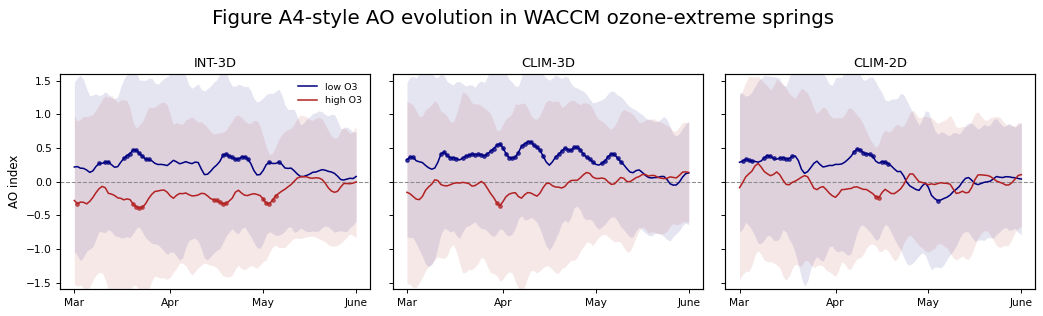

[PosixPath('/home/weiji/restart_exam/code_cleaned/Longrun/Visualization/plots/figureA4_waccm_ao_evolution_rm5.png'),
 PosixPath('/home/weiji/restart_exam/code_cleaned/Longrun/Visualization/plots/figureA4_waccm_ao_evolution_rm5.svg')]

In [27]:
def load_ao_daily(case):
    if is_composite_case(case):
        return pd.concat([load_ao_daily(component) for component in case_components(case)], ignore_index=True)
    df = pd.read_csv(CASES[case]['ao_csv'])
    date = df['Date'].astype(str)
    df['component'] = case
    df['year'] = date.str.slice(0, 4).astype(int)
    df['month'] = date.str.slice(5, 7).astype(int)
    df['day'] = date.str.slice(8, 10).astype(int)
    df['doy'] = date_to_doy_no_leap(df['year'] * 10000 + df['month'] * 100 + df['day'])
    val_col = 'AO_Index' if 'AO_Index' in df.columns else [c for c in df.columns if c.lower().startswith('ao')][0]
    return df[['component', 'year', 'doy', val_col]].rename(columns={val_col: 'ao'})


def print_ao_method_diagnostic():
    print('AO method check:')
    print('  Marina AO_evolution recomputes AO from 1000 hPa geopotential-height anomalies,')
    print('  interpolated to 73 latitudes, 20-90N, sqrt(cos(lat)) EOF weights, pcscaling=1,')
    print('  and an experiment-specific sign check.')
    print('  Our AO CSVs come from Nam_calculation.ipynb: 1000 hPa Z3 zonal mean, 20-90N every 2.5 deg,')
    print('  daily day-of-year anomalies, sqrt(cos(lat)) EOF weights, pcscaling=1, NaN-time filtering.')
    print('  Key differences to remember: BWCN is projected onto the B2000WCN reference EOF,')
    print('  INT-3D here is BWCN+B2000WCN merged, and the source experiment is not Marina CO2x1SmidEmin_yBWCN.')
    for case in ['INT-3D', 'CLIM-3D', 'CLIM-2D']:
        df = load_ao_daily(case)
        spring = df[(df.doy >= 60) & (df.doy <= 151)]['ao'].dropna()
        print(
            f'  {case}: Mar-May AO n={len(spring)}, '
            f'mean={spring.mean():+.3f}, std={spring.std():.3f}, '
            f'min/max={spring.min():+.3f}/{spring.max():+.3f}'
        )


def daily_composite_with_sig(df, years, value='ao', start=60, end=151):
    sub = filter_extreme_df(df, years)
    sub = sub[(sub.doy >= start) & (sub.doy <= end)].copy()
    sub['plot_day'] = sub.doy - start
    mean = sub.groupby('plot_day')[value].mean().reindex(np.arange(0, end - start + 1))
    std = sub.groupby('plot_day')[value].std().reindex(np.arange(0, end - start + 1))
    sig = []
    for d in mean.index:
        vals = sub.loc[sub.plot_day == d, value].dropna().values
        if len(vals) < 3:
            sig.append(False)
        else:
            sig.append(bool(ttest_1samp(vals, 0.0, nan_policy='omit').pvalue < 0.05))
    return mean, std, np.asarray(sig, dtype=bool)


print_ao_method_diagnostic()

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8), sharex=True, sharey=True)
for ax, case in zip(axes, ['INT-3D', 'CLIM-3D', 'CLIM-2D']):
    df = load_ao_daily(case)
    low = extreme_years(case, SAMPLE_LOW)
    high = extreme_years(case, SAMPLE_HIGH)
    low_mean, low_std, low_sig = daily_composite_with_sig(df, low)
    high_mean, high_std, high_sig = daily_composite_with_sig(df, high)
    x = low_mean.index.values
    ax.axhline(0, color='0.55', lw=0.9, ls='--')
    ax.plot(x, low_mean, color='navy', lw=1.3, label='low O3')
    ax.plot(x, high_mean, color='firebrick', lw=1.3, label='high O3')
    ax.fill_between(x, low_mean - low_std, low_mean + low_std, color='navy', alpha=0.10, lw=0)
    ax.fill_between(x, high_mean - high_std, high_mean + high_std, color='firebrick', alpha=0.10, lw=0)
    ax.scatter(x[low_sig], low_mean.values[low_sig], s=9, color='navy', alpha=0.70)
    ax.scatter(x[high_sig], high_mean.values[high_sig], s=9, color='firebrick', alpha=0.70)
    month_ticks_mar_may(ax)
    ax.set_title(case)
    ax.set_ylim(-1.6, 1.6)
    ax.set_yticks([-1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5])
axes[0].set_ylabel('AO index')
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle('Figure A4-style AO evolution in WACCM ozone-extreme springs')
fig.tight_layout()
save_and_show(fig, 'figureA4_waccm_ao_evolution_rm5')


## Figure A5: Eddy Heat Flux Anomalies


EHF method check:
  Marina heatflux_saes.ipynb uses nc_fid_epf['VTHETA'], removes the day-of-year climatology,
  applies a 30-day running mean to the daily anomaly series, then composites ozone-extreme years.
  Our daily EHF files store EHF_vTprime = [V*T]-[V][T], computed on CAM hybrid levels and log-p interpolated.
  For A5 only, the plotted series converts v'T' to a VTHETA-style v'theta' using (1000 hPa / p)^kappa at 100 hPa,
  and uses the same anomaly-then-30-day-running-mean order as Marina.


saved: /home/weiji/restart_exam/code_cleaned/Longrun/Visualization/plots/figureA5_waccm_ehf100_INT3D_only_rm5.png, /home/weiji/restart_exam/code_cleaned/Longrun/Visualization/plots/figureA5_waccm_ehf100_INT3D_only_rm5.svg


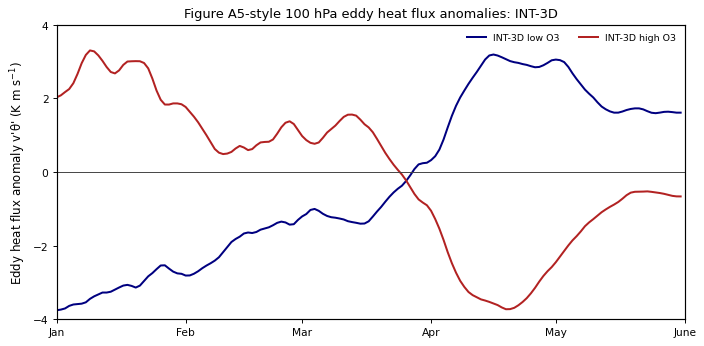

saved: /home/weiji/restart_exam/code_cleaned/Longrun/Visualization/plots/figureA5_waccm_ehf100_all_cases_rm5.png, /home/weiji/restart_exam/code_cleaned/Longrun/Visualization/plots/figureA5_waccm_ehf100_all_cases_rm5.svg


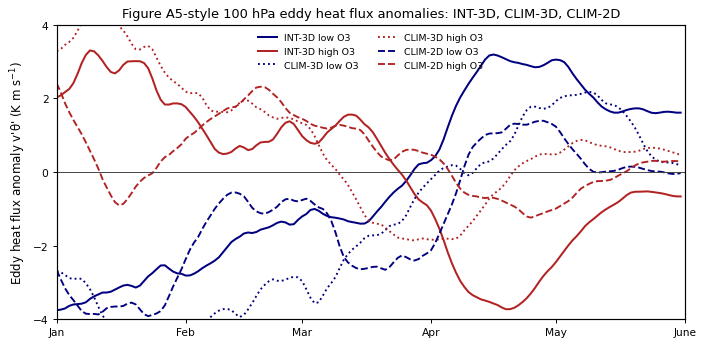

In [28]:
KAPPA_DRY_AIR = 287.0 / 1004.0
A5_START_DOY = 1
A5_END_DOY = 151  # Jan-May data with a June boundary tick, matching Marina heatflux_saes.ipynb.
_EHF_FALLBACK_WARNED = set()


def month_ticks_jan_june_boundary(ax):
    ax.set_xlim(0, A5_END_DOY - A5_START_DOY + 1)
    ax.set_xticks([0, 31, 59, 90, 120, 151])
    ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June'])


def preferred_ehf_path(case):
    current = Path(CASES[case]['ehf_nc'])
    current_text = str(current)
    if '_vTprime_vThetaprime_' in current_text:
        preferred = current
        fallback = Path(current_text.replace('_vTprime_vThetaprime_', '_vTprime_'))
    else:
        preferred = Path(current_text.replace('_vTprime_', '_vTprime_vThetaprime_'))
        fallback = current
    if preferred.exists():
        return preferred
    if fallback.exists():
        return fallback
    return preferred


def load_ehf100_daily(case, flux_var='EHF_vThetaprime'):
    if is_composite_case(case):
        return pd.concat([load_ehf100_daily(component, flux_var=flux_var) for component in case_components(case)], ignore_index=True)

    path = preferred_ehf_path(case)
    with xr.open_dataset(path, decode_times=False) as ds:
        if flux_var in ds:
            da = ds[flux_var]
            source_var = flux_var
            fallback_used = False
        elif flux_var == 'EHF_vThetaprime' and 'EHF_vTprime' in ds:
            da = ds['EHF_vTprime']
            source_var = 'EHF_vTprime'
            fallback_used = True
        else:
            raise KeyError(f'{flux_var} not found in {path}; available={list(ds.data_vars)}')

        da = select_plev_hpa(da, 100.0)
        selected_hpa = float(np.asarray(da['plev'].values))
        if fallback_used:
            warn_key = (case, str(path), flux_var)
            if warn_key not in _EHF_FALLBACK_WARNED:
                print(
                    f'[A5 WARN] {path.name} has no {flux_var}; using old {source_var} '
                    f'and plotting an approximate pressure-level conversion. '
                    'Rerun Eddyheatflux.ipynb to write the exact hybrid-level vThetaprime.'
                )
                _EHF_FALLBACK_WARNED.add(warn_key)
            da = da * (1000.0 / selected_hpa) ** KAPPA_DRY_AIR

        da = coslat_weighted_mean(da, 45, 75)
        vals = da.load().values.astype(float)
        years, doys = calendar_from_dataset(ds)
    return pd.DataFrame({'component': case, 'year': years, 'doy': doys, 'ehf': vals})


def prepare_ehf_anomaly(df, value='ehf', rolling=30):
    out = df.copy().sort_values(['component', 'year', 'doy']).reset_index(drop=True)
    out['anom'] = out[value] - out.groupby('doy')[value].transform('mean')
    if rolling:
        out['anom_rm'] = (
            out.groupby('component', group_keys=False)['anom']
            .transform(lambda s: s.rolling(window=rolling, center=True, min_periods=max(3, rolling // 3)).mean())
        )
    else:
        out['anom_rm'] = out['anom']
    return out


def ehf_anomaly_composite(prepared_df, years, start=A5_START_DOY, end=A5_END_DOY):
    sub = filter_extreme_df(prepared_df, years)
    sub = sub[(sub.doy >= start) & (sub.doy <= end)].copy()
    sub['plot_day'] = sub.doy - start
    return sub.groupby('plot_day')['anom_rm'].mean().reindex(np.arange(0, end - start + 1))


def print_ehf_method_diagnostic():
    print('EHF method check:')
    print("  Eddyheatflux.ipynb now writes both EHF_vTprime and EHF_vThetaprime.")
    print("  EHF_vTprime     = [V*T] - [V][T].")
    print("  EHF_vThetaprime = [V*theta] - [V][theta], theta = T*(100000 Pa/p_mid)^(287/1004),")
    print('  computed on hybrid levels first and then log-p interpolated to the output pressure grid.')
    print('  If only old vTprime files are present, this plotting cell falls back to an approximate')
    print('  pressure-level conversion for the vThetaprime preview and prints a warning.')


def plot_a5_cases(cases_and_styles, flux_var, stem, title, ylabel, ylim, yticks):
    fig, ax = plt.subplots(figsize=(8.5, 4.3))
    for case, ls, lw in cases_and_styles:
        df = load_ehf100_daily(case, flux_var=flux_var)
        prepared = prepare_ehf_anomaly(df, rolling=30)
        low = ehf_anomaly_composite(prepared, extreme_years(case, SAMPLE_LOW))
        high = ehf_anomaly_composite(prepared, extreme_years(case, SAMPLE_HIGH))
        x = low.index.values
        ax.plot(x, low, color='navy', ls=ls, lw=lw, label=f'{case} low O3')
        ax.plot(x, high, color='firebrick', ls=ls, lw=lw, label=f'{case} high O3')
    ax.axhline(0, color='0.25', lw=0.8)
    month_ticks_jan_june_boundary(ax)
    ax.set_ylim(*ylim)
    ax.set_yticks(yticks)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(ncol=2, fontsize=8, frameon=False)
    fig.tight_layout()
    save_and_show(fig, stem)
    return fig


print_ehf_method_diagnostic()

A5_CASE_SETS = {
    'INT3D_only': ([('INT-3D', '-', 1.7)], 'INT-3D'),
    'all_cases': ([('INT-3D', '-', 1.7), ('CLIM-3D', ':', 1.6), ('CLIM-2D', '--', 1.6)], 'INT-3D, CLIM-3D, CLIM-2D'),
}

for suffix, (case_styles, case_title) in A5_CASE_SETS.items():
    plot_a5_cases(
        case_styles,
        flux_var='EHF_vTprime',
        stem=f'figureA5_waccm_ehf100_vTprime_{suffix}_rm5',
        title=f"Figure A5-style 100 hPa v'T' anomalies: {case_title}",
        ylabel="Eddy heat flux anomaly v'T' (K m s$^{-1}$)",
        ylim=(-2.5, 2.5),
        yticks=[-2, -1, 0, 1, 2],
    )
    plot_a5_cases(
        case_styles,
        flux_var='EHF_vThetaprime',
        stem=f'figureA5_waccm_ehf100_vThetaprime_{suffix}_rm5',
        title=f"Figure A5-style 100 hPa v'\\theta' anomalies: {case_title}",
        ylabel=r"Eddy heat flux anomaly v'$\theta$' (K m s$^{-1}$)",
        ylim=(-4, 4),
        yticks=[-4, -2, 0, 2, 4],
    )


## Figure A6: Ozone Anomalies, Available-Data Subset

The current local climatology outputs include O3 but not QRS/QRS_TOT shortwave-heating climatologies, so this section plots only the available WACCM O3 anomaly panels.


/tmp/ipykernel_1369409/657531522.py:152: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cf = ax.contourf(x, y, da.values, levels=levels, cmap=plt.cm.get_cmap(cmap), extend='both')
/tmp/ipykernel_1369409/657531522.py:152: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cf = ax.contourf(x, y, da.values, levels=levels, cmap=plt.cm.get_cmap(cmap), extend='both')


saved: /home/weiji/restart_exam/code_cleaned/Longrun/Visualization/plots/figureA6_waccm_o3_anomalies_available_rm5.png, /home/weiji/restart_exam/code_cleaned/Longrun/Visualization/plots/figureA6_waccm_o3_anomalies_available_rm5.svg


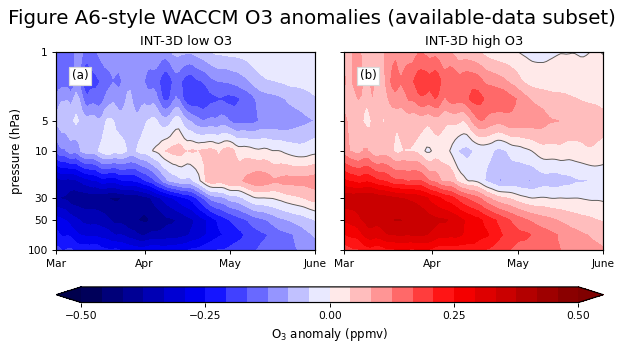

Shortwave-heating panels from Figure A6 were skipped: QRS/QRS_TOT climatology is not present in the current timefixed outputs.


In [29]:
def load_o3_anomaly_section(case, sample):
    sample_da = load_clim_da(case, 'O3', sample)
    all_da = load_clim_da(case, 'O3', 'all')
    da = (sample_da - all_da) * 1.0e6  # mol/mol -> ppmv
    return reduce_time_plev_lat(da, lat_band=(60, 90), plev_range=(1, 100), doy_slice=slice(59, 151))


fig, axes = plt.subplots(1, 2, figsize=(7.2, 4.0), sharex=True, sharey=True, constrained_layout=True)
levels = np.linspace(-0.5, 0.5, 25)
cf = plot_logp_panel(axes[0], load_o3_anomaly_section('INT-3D', SAMPLE_LOW), levels, title='INT-3D low O3', label='(a)')
plot_logp_panel(axes[1], load_o3_anomaly_section('INT-3D', SAMPLE_HIGH), levels, title='INT-3D high O3', label='(b)')
for ax in axes:
    ax.set_ylim(np.log(100), np.log(1))
    ticks = np.array([100, 50, 30, 10, 5, 1])
    ax.set_yticks(np.log(ticks))
    ax.set_yticklabels([str(t) for t in ticks])
axes[0].set_ylabel('pressure (hPa)')
cbar = fig.colorbar(cf, ax=axes, orientation='horizontal', pad=0.08, aspect=35, ticks=[-0.5, -0.25, 0, 0.25, 0.5])
cbar.set_label('O$_3$ anomaly (ppmv)')
fig.suptitle('Figure A6-style WACCM O3 anomalies (available-data subset)')
save_and_show(fig, 'figureA6_waccm_o3_anomalies_available_rm5')

print('Shortwave-heating panels from Figure A6 were skipped: QRS/QRS_TOT climatology is not present in the current timefixed outputs.')
